1. Análisis exploratorio de datos (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

X = pd.read_parquet("X_t0.parquet")
y = pd.read_parquet("y_t0.parquet")

# Combinar los datos para facilitar el análisis (si la variable objetivo es relevante)
data = X.copy()
data["target"] = y.values

print(data.head())

   borrow_block_number  borrow_timestamp  \
0              7711117      1.557197e+09   
1              7711123      1.557197e+09   
2              7711126      1.557197e+09   
3              7711672      1.557205e+09   
4              7712572      1.557217e+09   

                               wallet_address  first_tx_timestamp  \
0  0x502cb8985b2c92a8d4bf309cdaa89de9be442708        1.537224e+09   
1  0x502cb8985b2c92a8d4bf309cdaa89de9be442708        1.537224e+09   
2  0x502cb8985b2c92a8d4bf309cdaa89de9be442708        1.537224e+09   
3  0xa7ff0d561cd15ed525e31bbe0af3fe34ac2059f6        1.557191e+09   
4  0xbd9ed130a53cfafcf81502e4d35329a6c4d53410        1.557217e+09   

   last_tx_timestamp  wallet_age  incoming_tx_count  outgoing_tx_count  \
0       1.557197e+09  19973049.0                199                438   
1       1.557197e+09  19973188.0                200                439   
2       1.557197e+09  19973238.0                201                440   
3       1.557198e+09    

In [4]:
X.info


<bound method DataFrame.info of        borrow_block_number  borrow_timestamp  \
0                  7711117      1.557197e+09   
1                  7711123      1.557197e+09   
2                  7711126      1.557197e+09   
3                  7711672      1.557205e+09   
4                  7712572      1.557217e+09   
...                    ...               ...   
44291             10336599      1.593110e+09   
44292             10336621      1.593110e+09   
44293             10336624      1.593110e+09   
44294             10336627      1.593110e+09   
44295             10336628      1.593110e+09   

                                   wallet_address  first_tx_timestamp  \
0      0x502cb8985b2c92a8d4bf309cdaa89de9be442708        1.537224e+09   
1      0x502cb8985b2c92a8d4bf309cdaa89de9be442708        1.537224e+09   
2      0x502cb8985b2c92a8d4bf309cdaa89de9be442708        1.537224e+09   
3      0xa7ff0d561cd15ed525e31bbe0af3fe34ac2059f6        1.557191e+09   
4      0xbd9ed130a53cfafcf

In [5]:
# Dimensiones del conjunto de datos
print("Dimensiones del conjunto de datos:", data.shape)

# Información general del conjunto de datos
print("\nInformación del dataset:")
print(data.info())

# Resumen estadístico de las variables numéricas
print("\nResumen estadístico:")
print(data.describe())


Dimensiones del conjunto de datos: (44296, 78)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44296 entries, 0 to 44295
Data columns (total 78 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   borrow_block_number                      44296 non-null  int64  
 1   borrow_timestamp                         44296 non-null  float64
 2   wallet_address                           44296 non-null  object 
 3   first_tx_timestamp                       44296 non-null  float64
 4   last_tx_timestamp                        44296 non-null  float64
 5   wallet_age                               44296 non-null  float64
 6   incoming_tx_count                        44296 non-null  int64  
 7   outgoing_tx_count                        44296 non-null  int64  
 8   net_incoming_tx_count                    44296 non-null  int64  
 9   total_gas_paid_eth                       44

In [6]:
# Verificar valores nulos
print("\nValores nulos por columna:")
print(data.isnull().sum())

# Porcentaje de datos nulos
null_percentage = data.isnull().mean() * 100
print("\nPorcentaje de datos nulos:")
print(null_percentage[null_percentage > 0])

# Verificar duplicados
print("\nNúmero de filas duplicadas:", data.duplicated().sum())



Valores nulos por columna:
borrow_block_number              0
borrow_timestamp                 0
wallet_address                   0
first_tx_timestamp               0
last_tx_timestamp                0
                                ..
market_rocp                      0
market_rocr                      0
unique_borrow_protocol_count     0
unique_lending_protocol_count    0
target                           0
Length: 78, dtype: int64

Porcentaje de datos nulos:
Series([], dtype: float64)

Número de filas duplicadas: 0


/tmp/ipykernel_629786/2487388610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=data, palette="viridis")


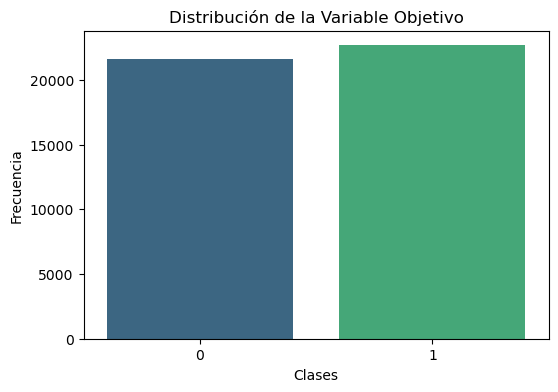


Balance de clases (%):
target
1    51.14683
0    48.85317
Name: proportion, dtype: float64


In [7]:
# Distribución de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=data, palette="viridis")
plt.title("Distribución de la Variable Objetivo")
plt.xlabel("Clases")
plt.ylabel("Frecuencia")
plt.show()

# Balance de clases
class_balance = data["target"].value_counts(normalize=True) * 100
print("\nBalance de clases (%):")
print(class_balance)


In [8]:
# Valores nulos
print(data.isnull().sum())

# Identificar variables categóricas y numéricas
numericas = data.select_dtypes(include=["float", "int"]).columns
categoricas = data.select_dtypes(include=["object", "category"]).columns

print("Variables numéricas:", numericas)
print("Variables categóricas:", categoricas)


borrow_block_number              0
borrow_timestamp                 0
wallet_address                   0
first_tx_timestamp               0
last_tx_timestamp                0
                                ..
market_rocp                      0
market_rocr                      0
unique_borrow_protocol_count     0
unique_lending_protocol_count    0
target                           0
Length: 78, dtype: int64
Variables numéricas: Index(['borrow_block_number', 'borrow_timestamp', 'first_tx_timestamp',
       'last_tx_timestamp', 'wallet_age', 'incoming_tx_count',
       'outgoing_tx_count', 'net_incoming_tx_count', 'total_gas_paid_eth',
       'avg_gas_paid_per_tx_eth', 'risky_tx_count',
       'risky_unique_contract_count', 'risky_first_tx_timestamp',
       'risky_last_tx_timestamp', 'risky_first_last_tx_timestamp_diff',
       'risky_sum_outgoing_amount_eth', 'outgoing_tx_sum_eth',
       'incoming_tx_sum_eth', 'outgoing_tx_avg_eth', 'incoming_tx_avg_eth',
       'max_eth_ever', 'min_et

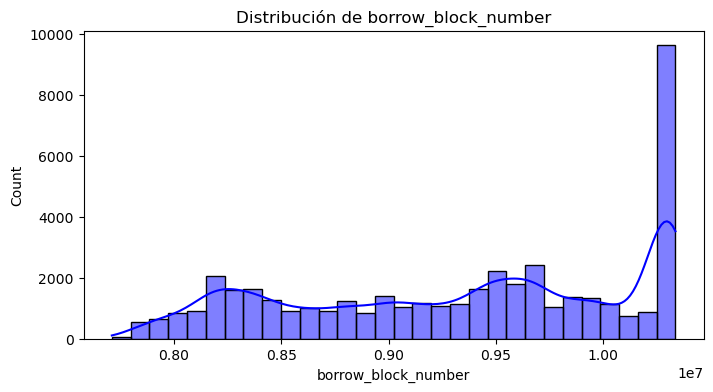

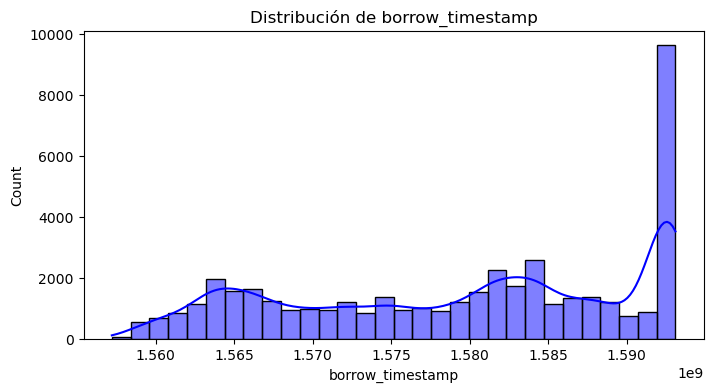

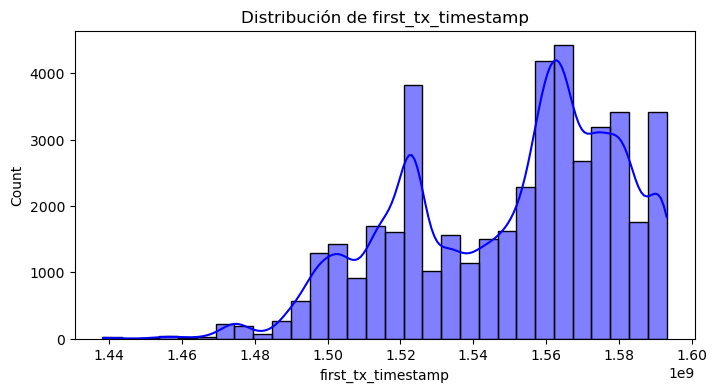

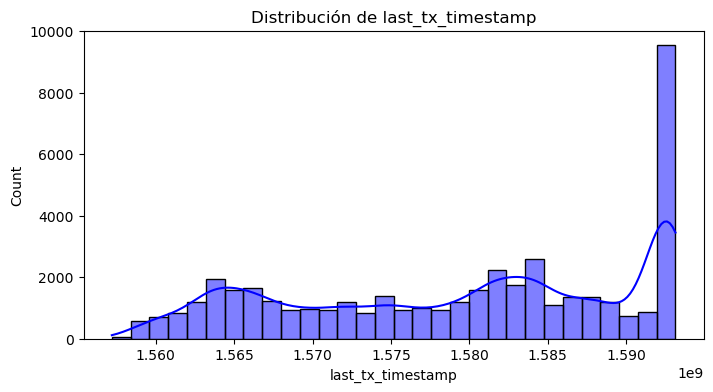

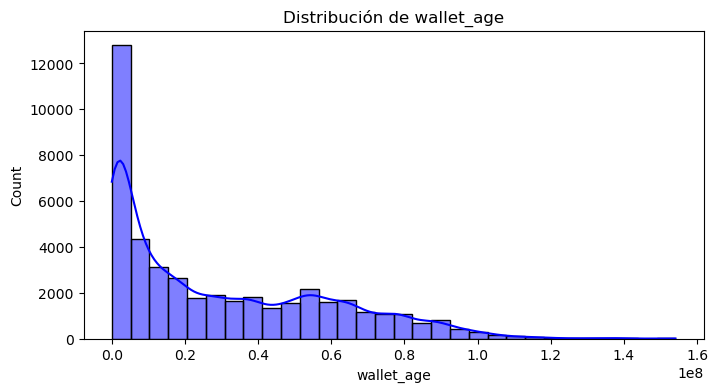

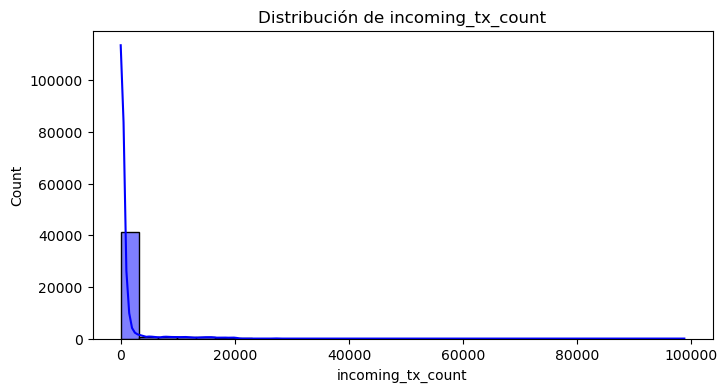

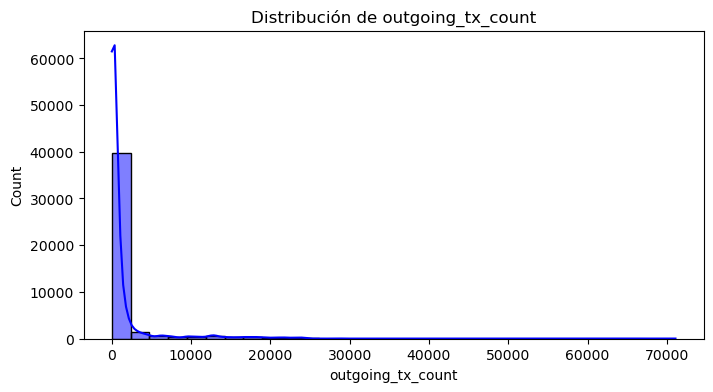

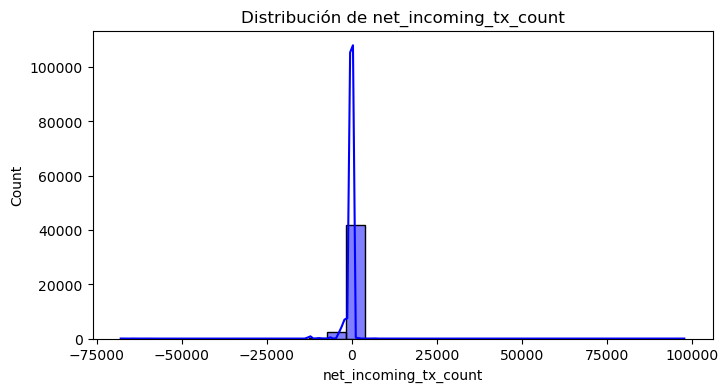

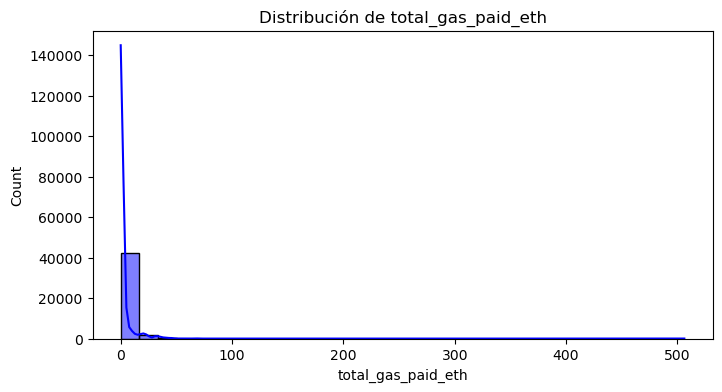

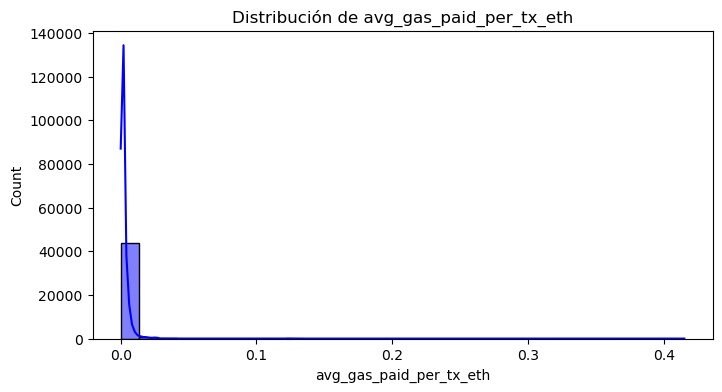

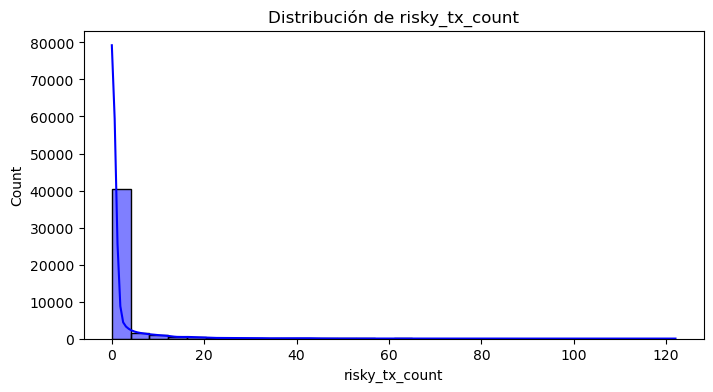

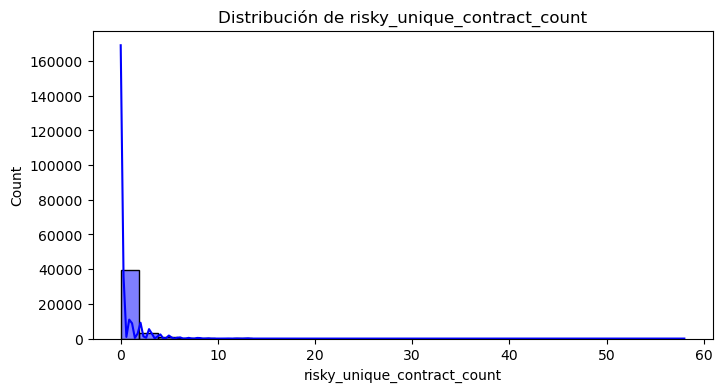

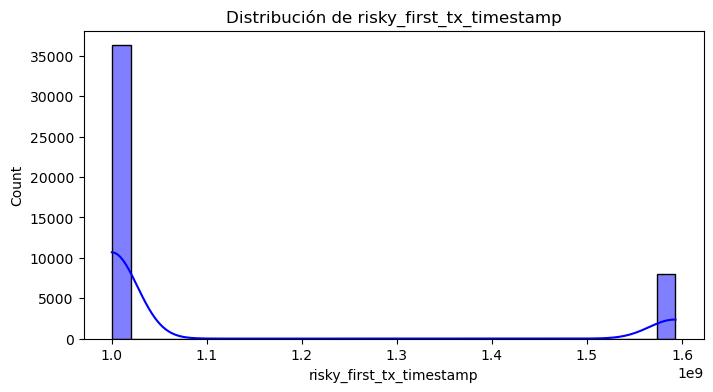

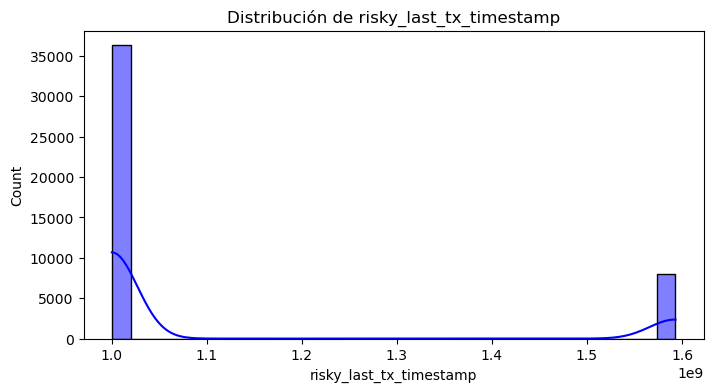

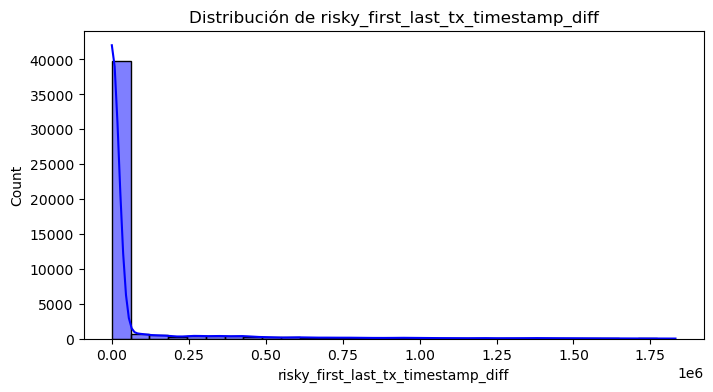

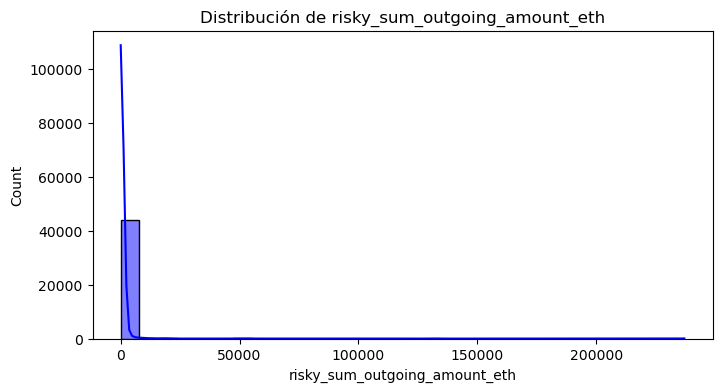

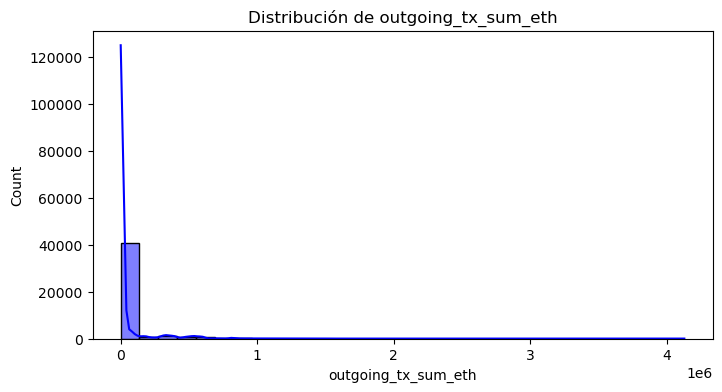

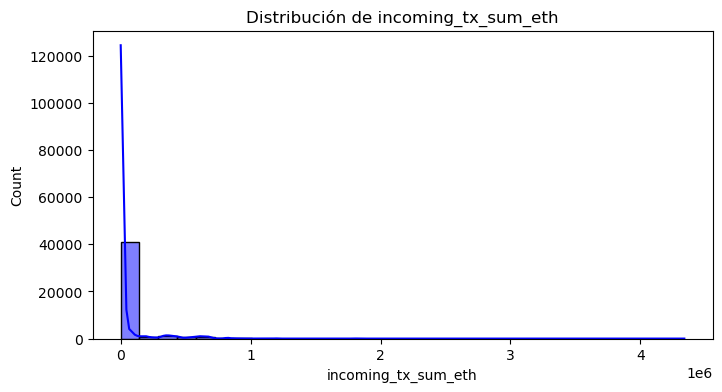

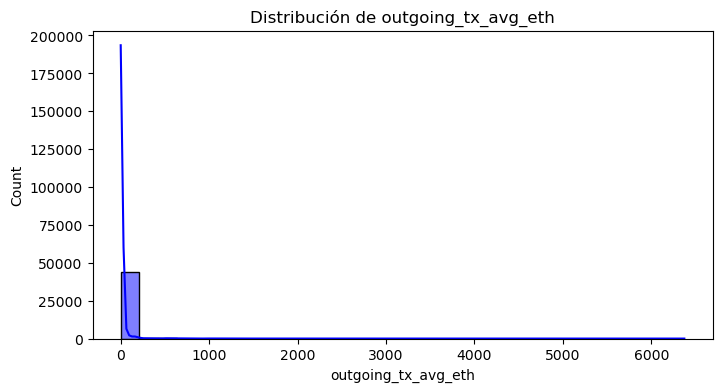

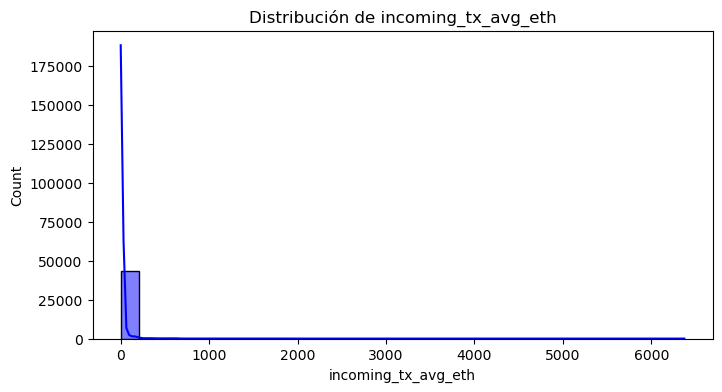

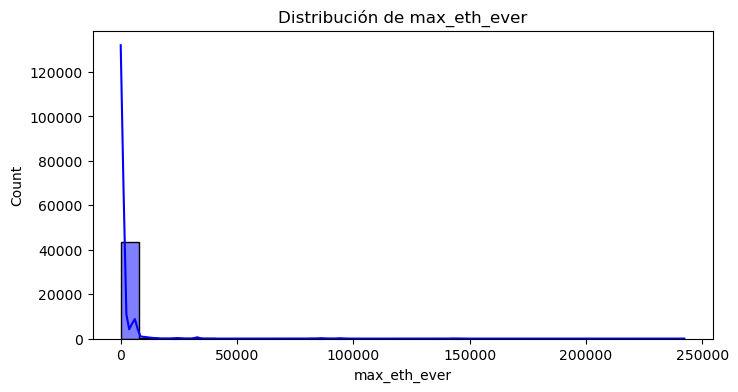

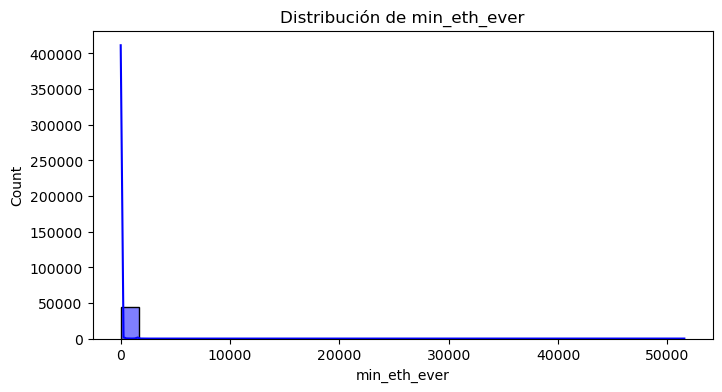

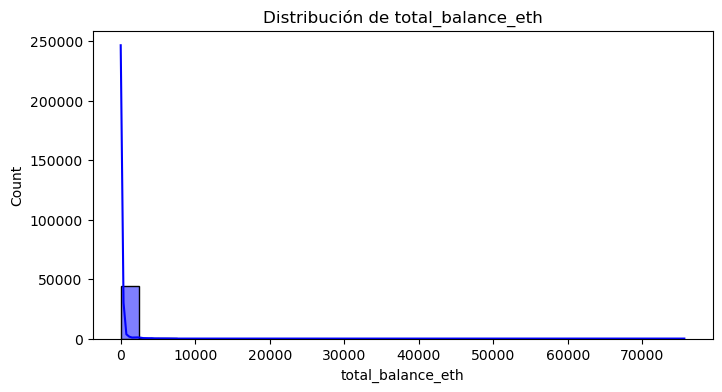

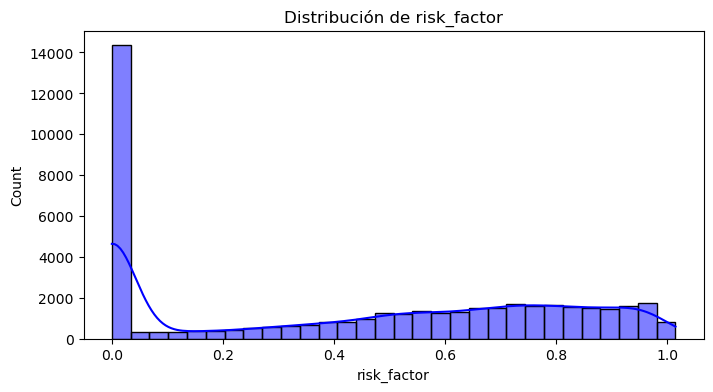

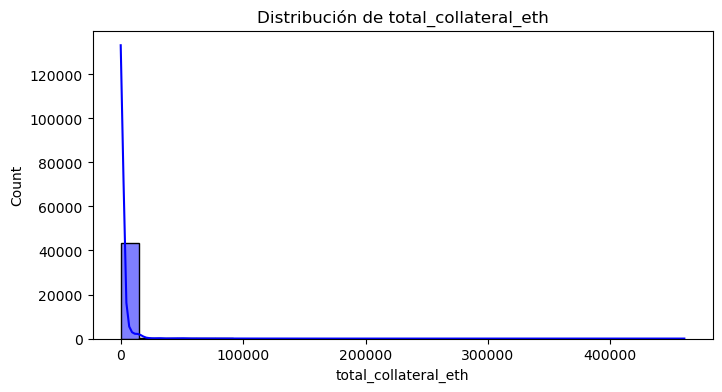

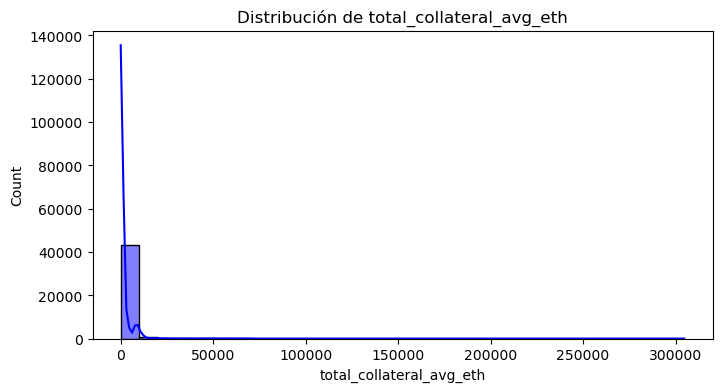

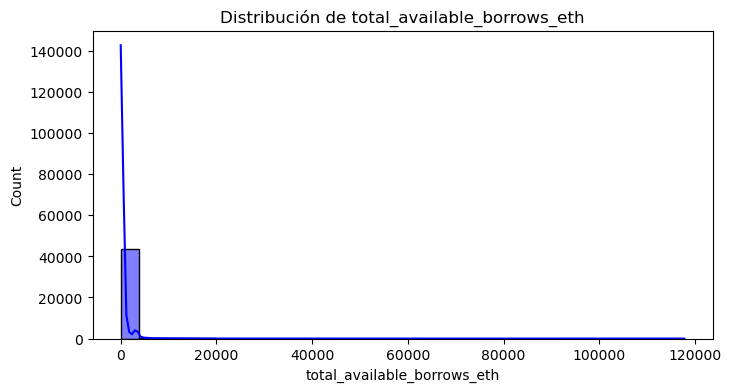

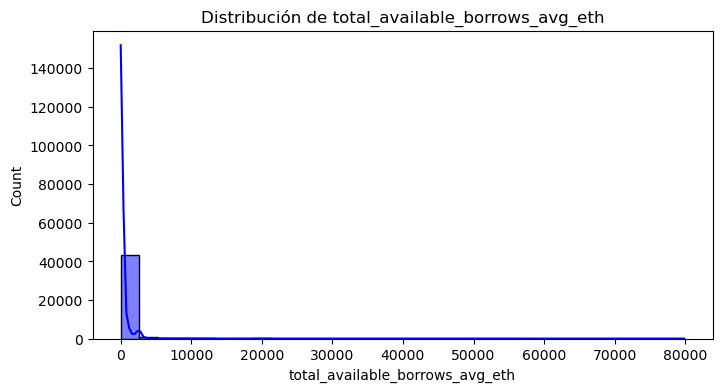

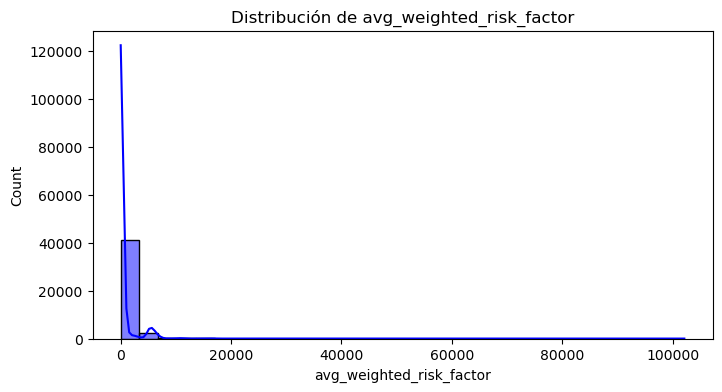

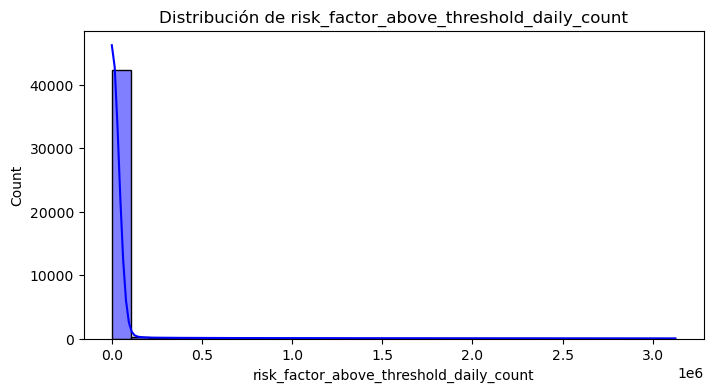

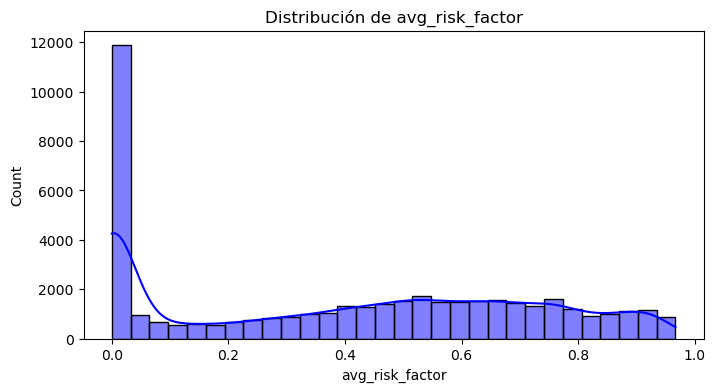

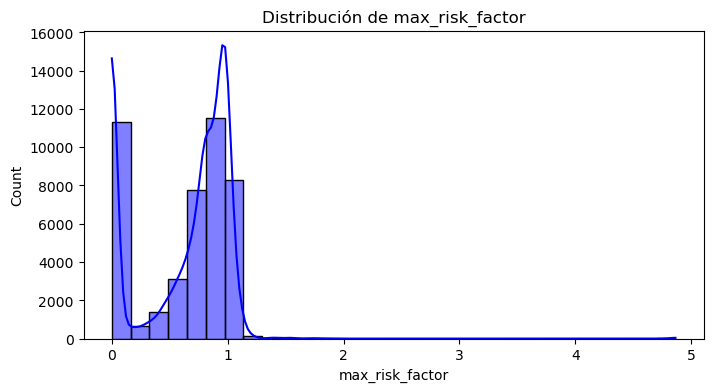

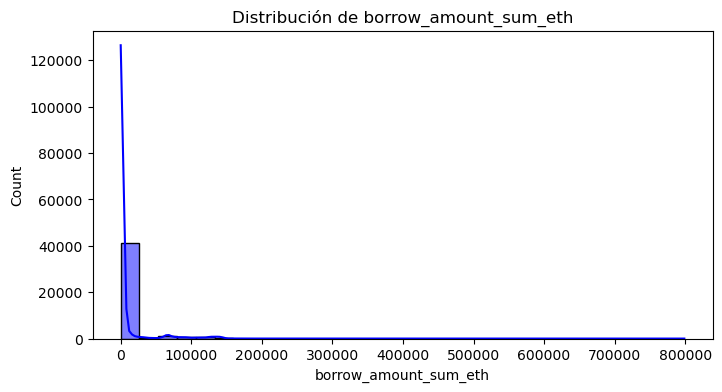

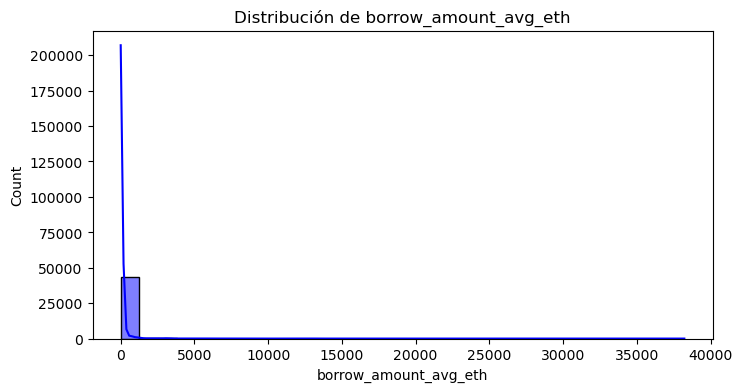

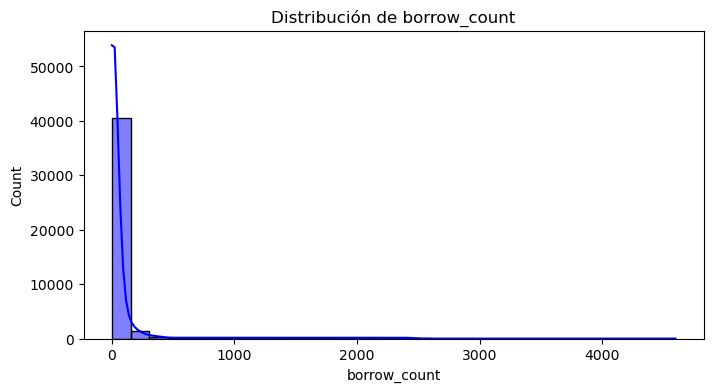

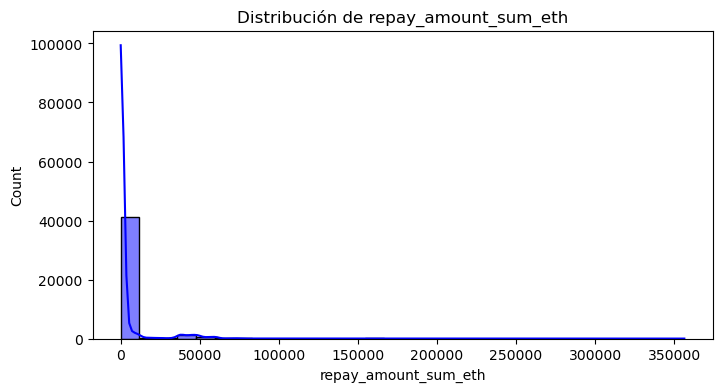

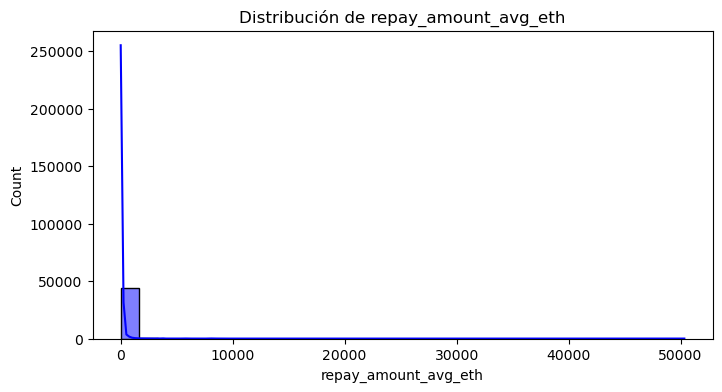

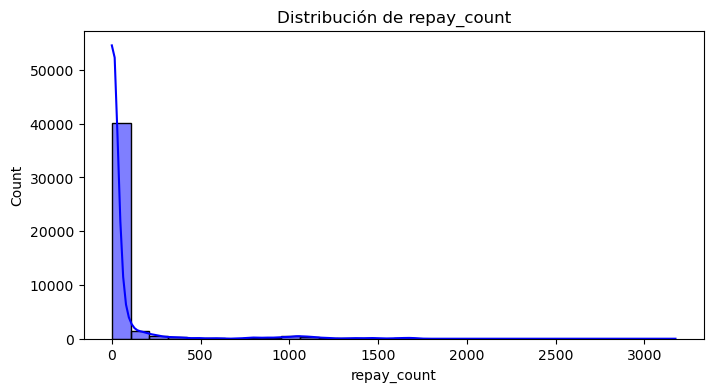

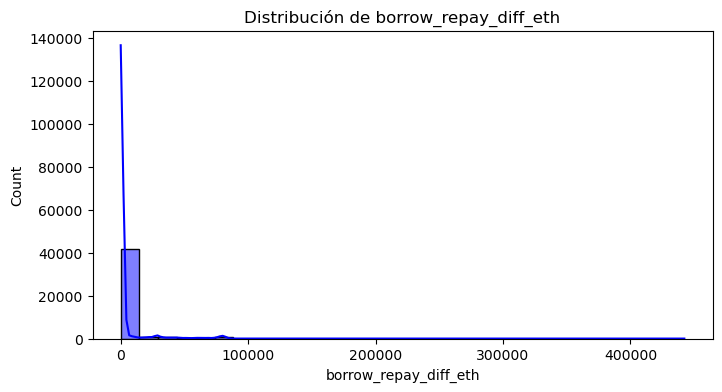

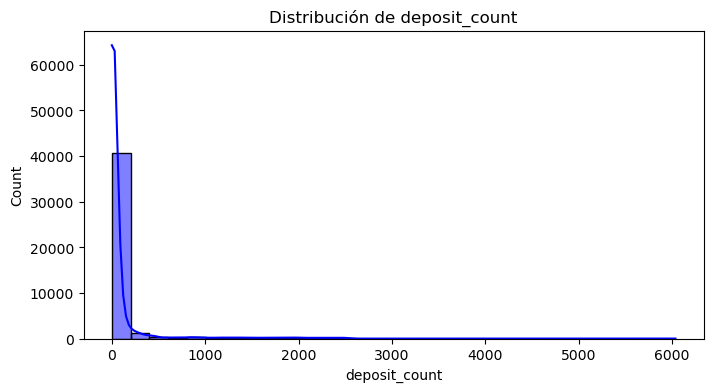

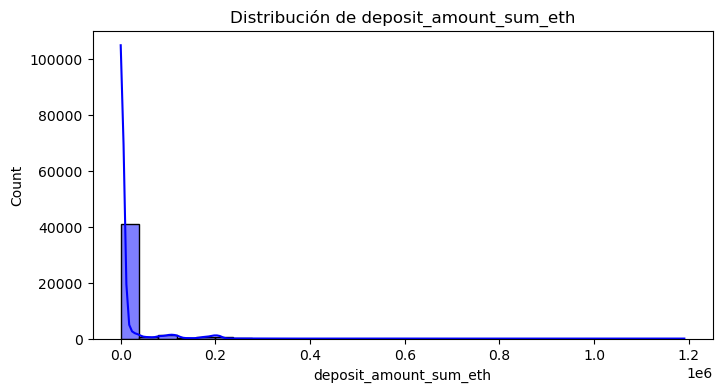

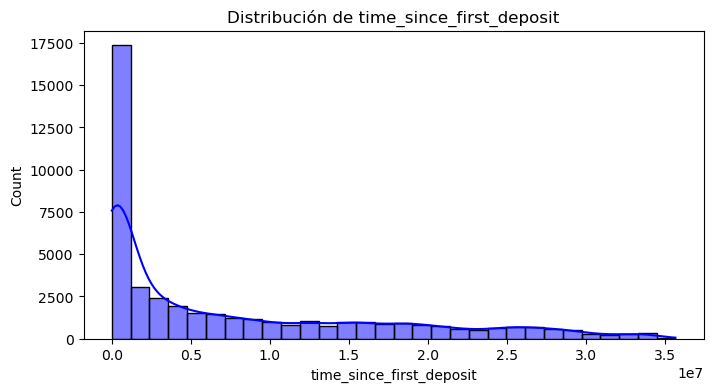

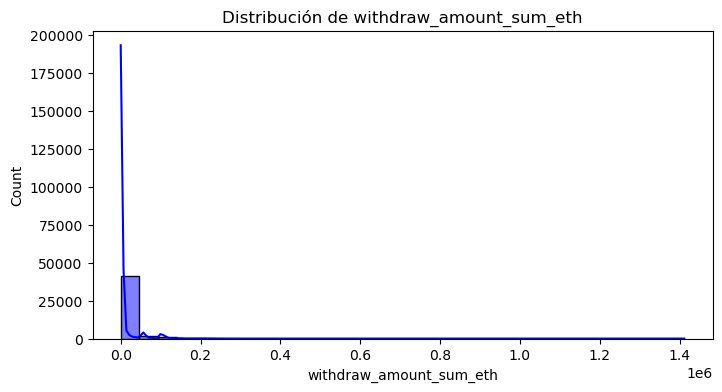

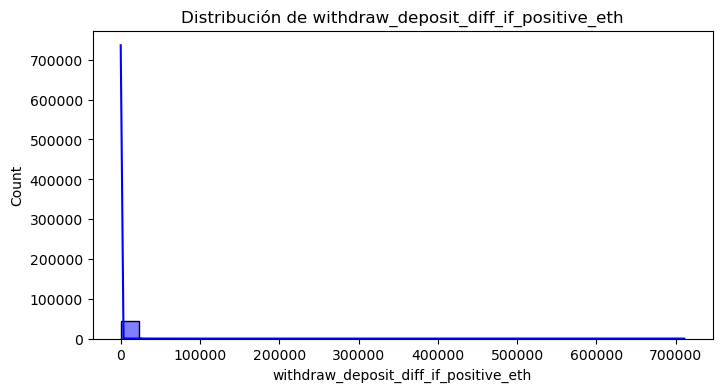

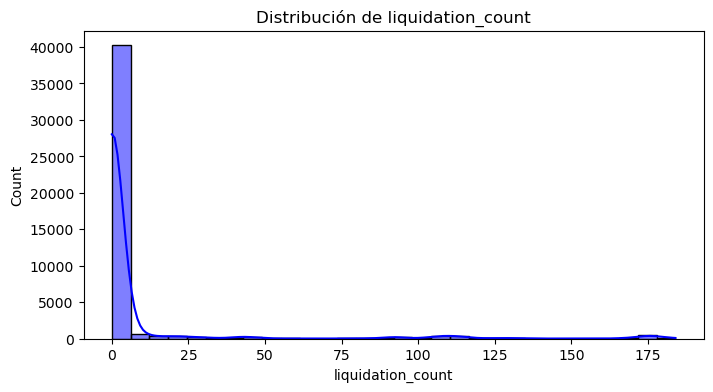

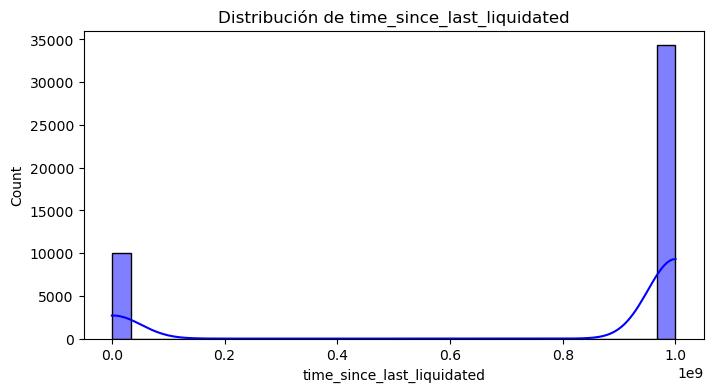

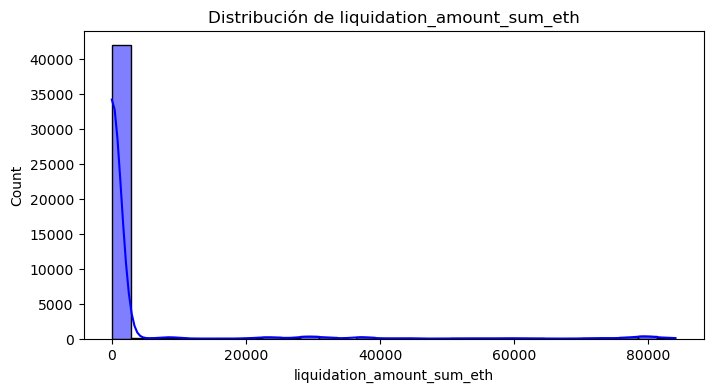

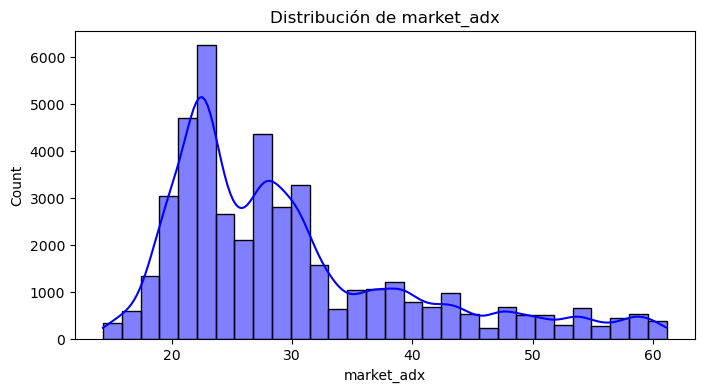

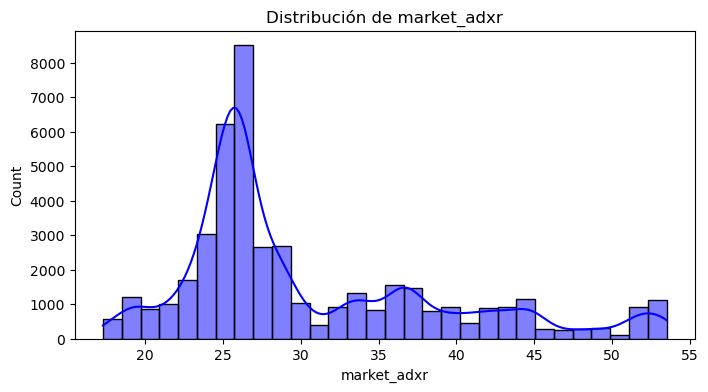

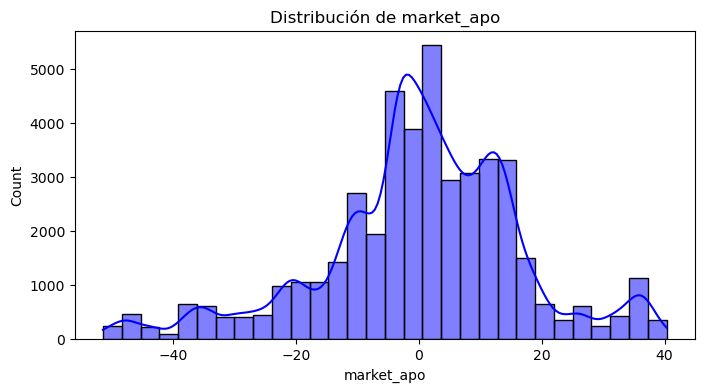

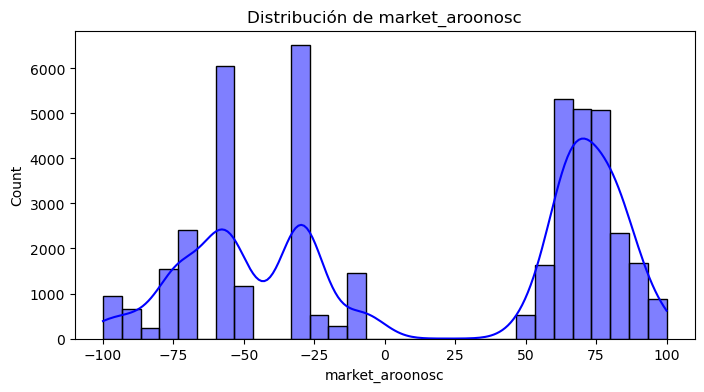

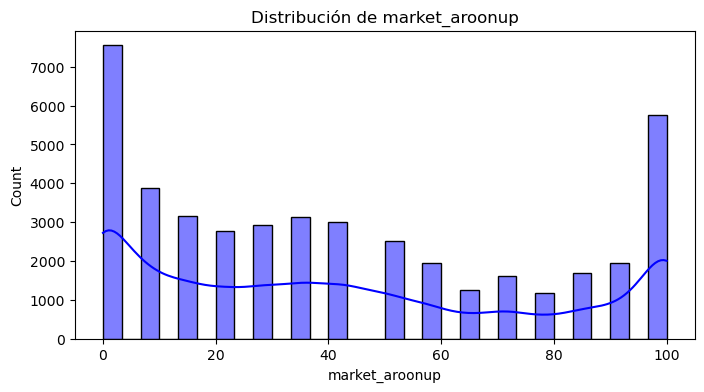

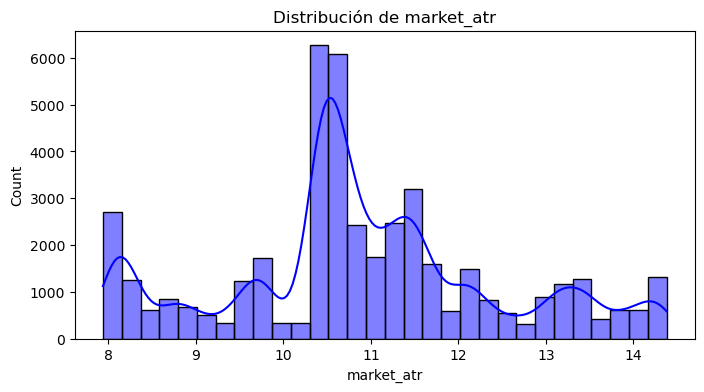

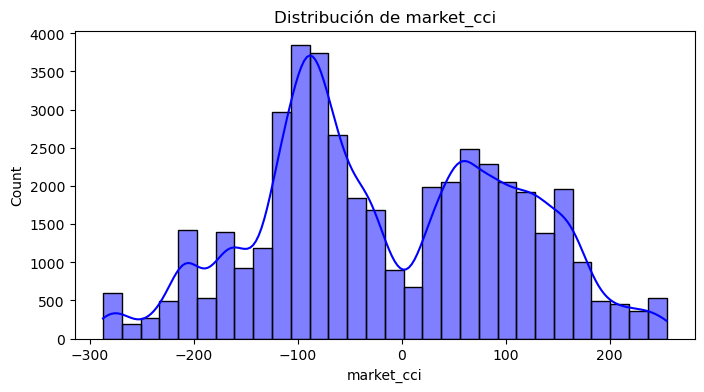

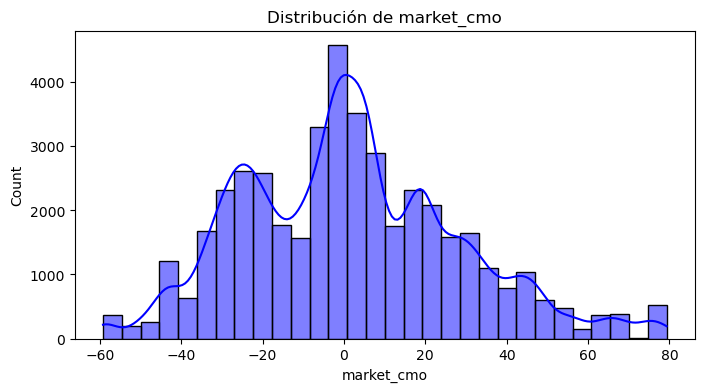

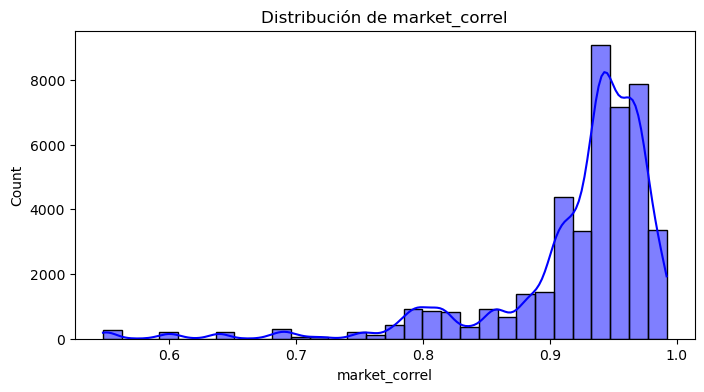

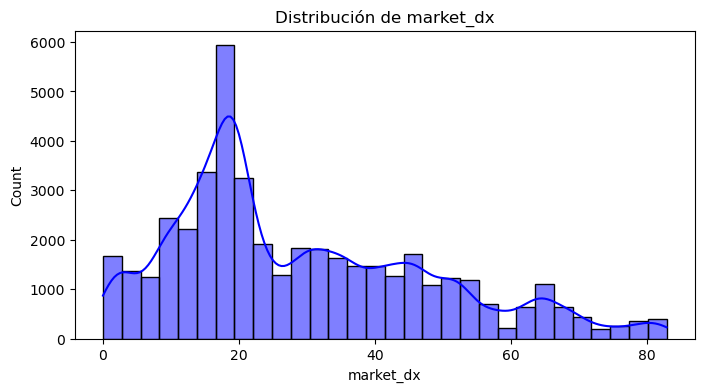

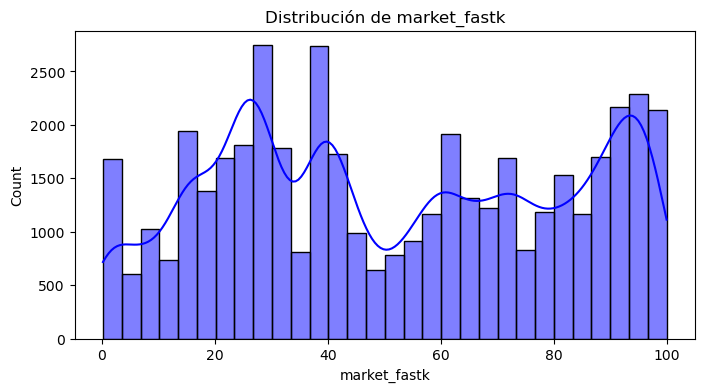

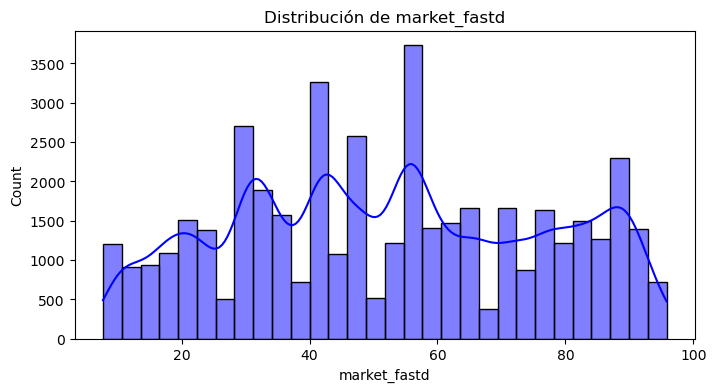

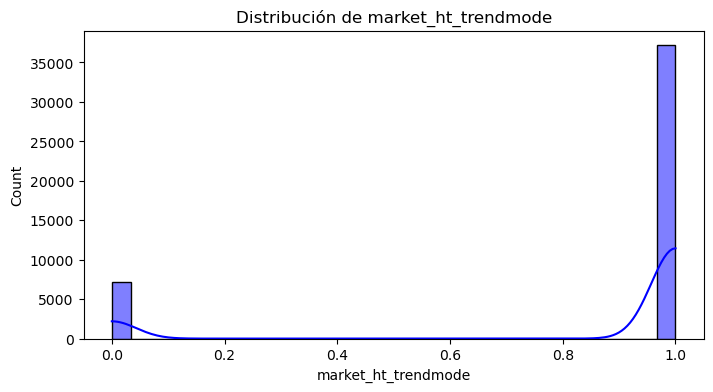

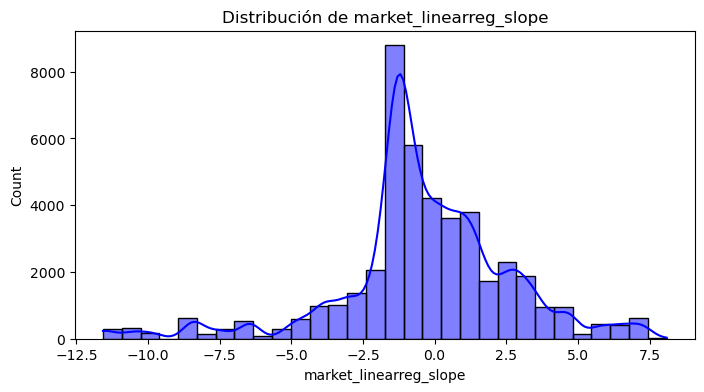

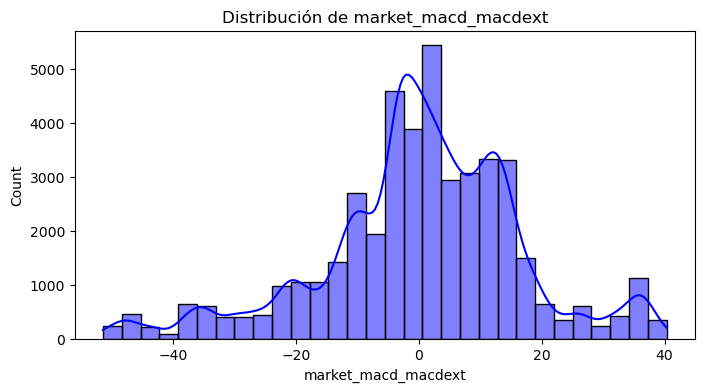

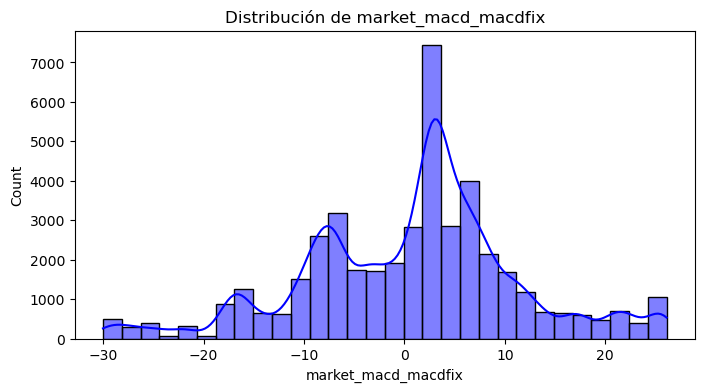

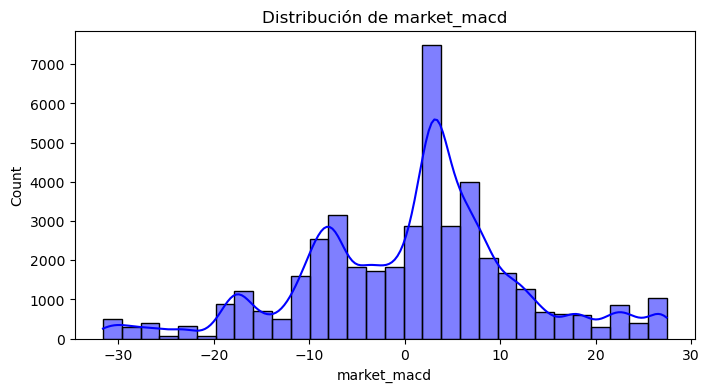

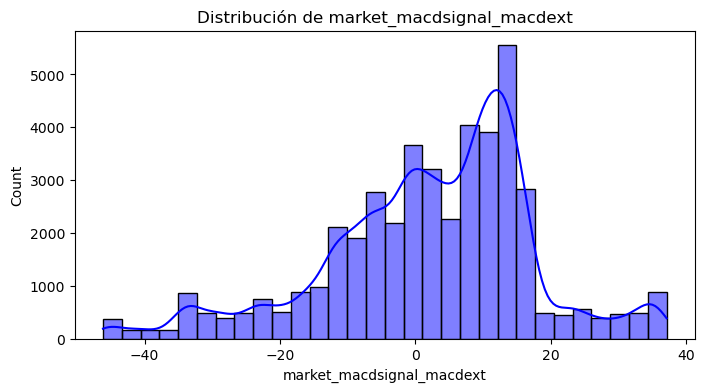

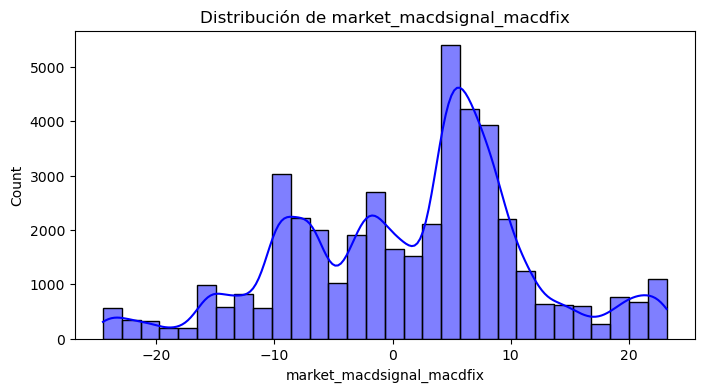

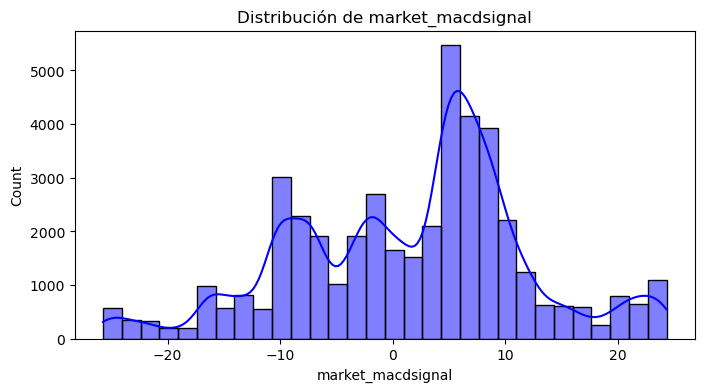

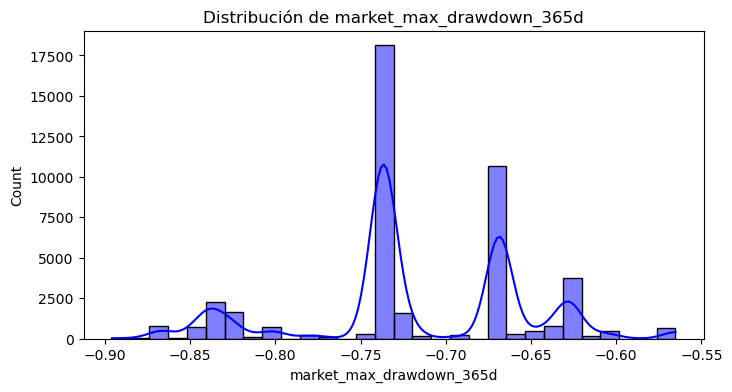

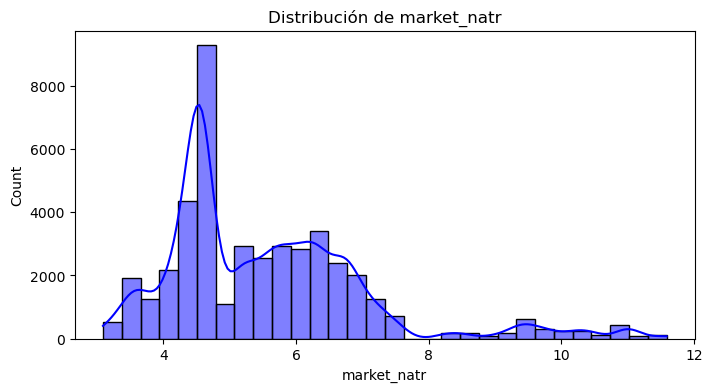

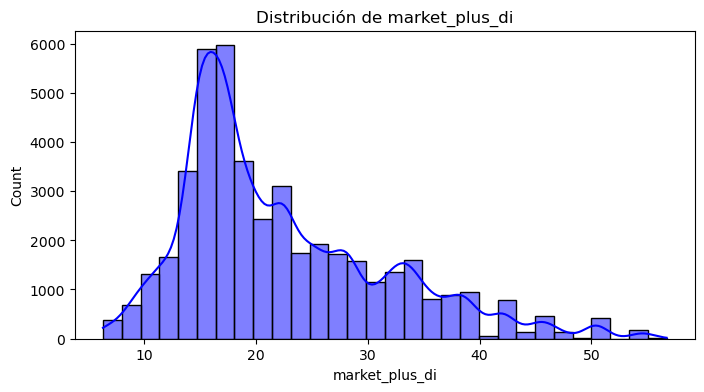

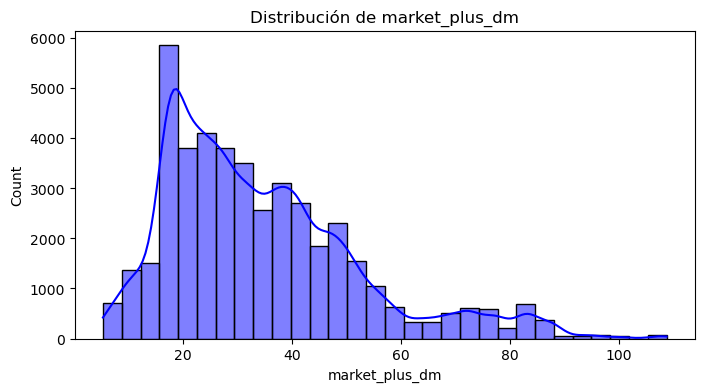

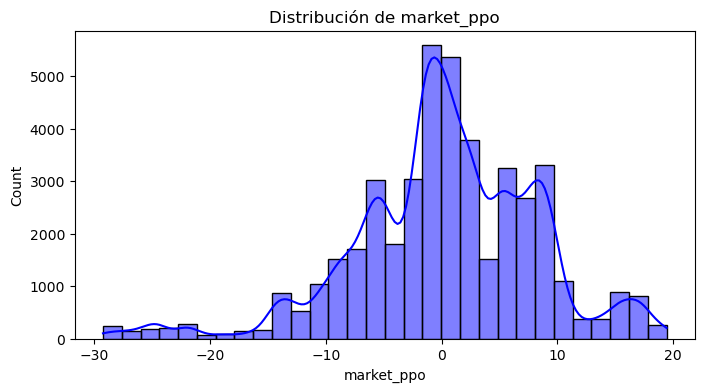

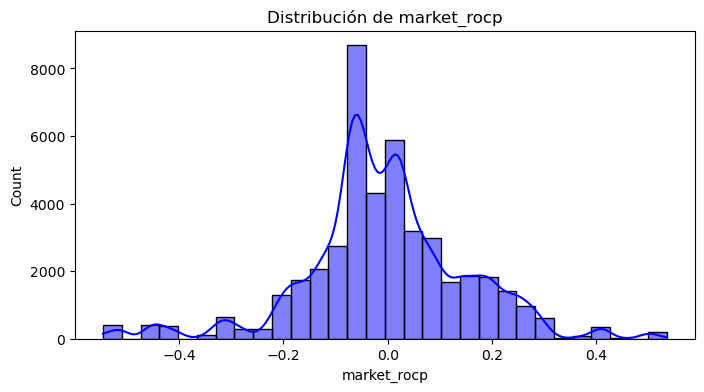

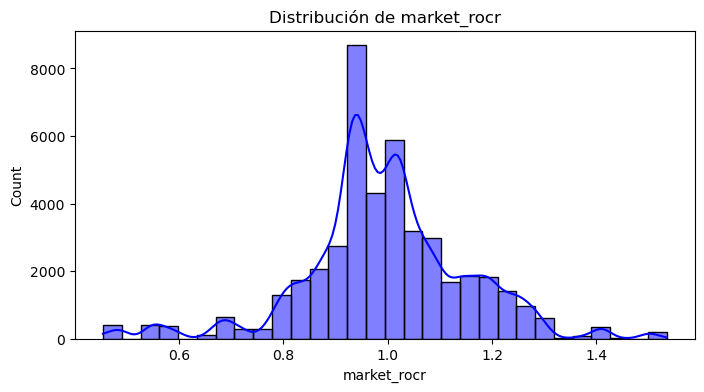

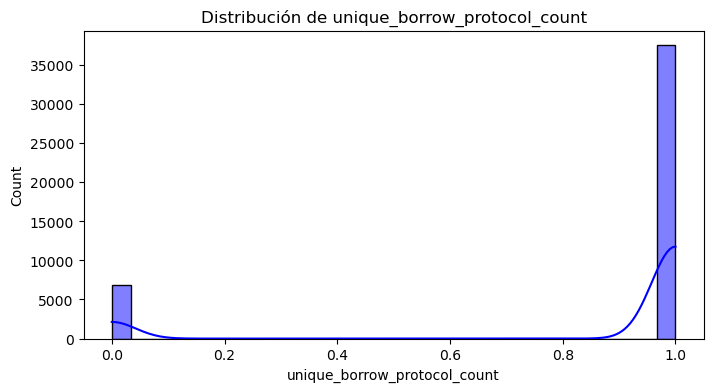

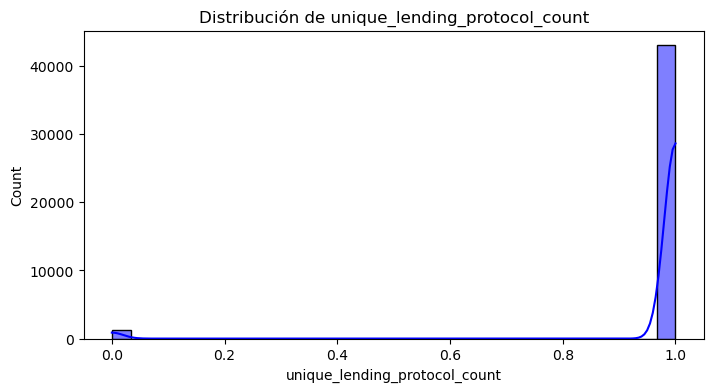

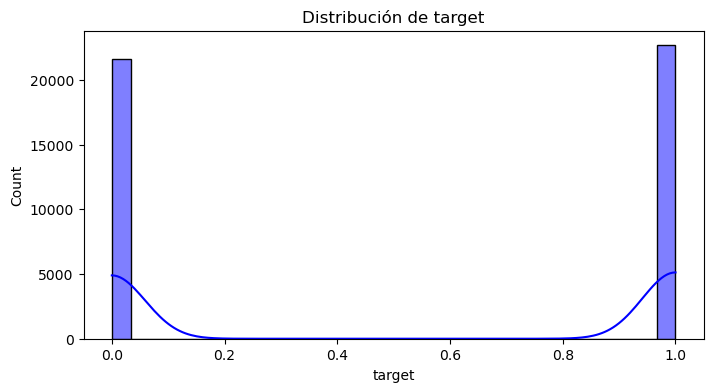

In [9]:
# Distribuciones de las variables numéricas
for col in numericas:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[col], kde=True, bins=30, color="blue")
    plt.title(f"Distribución de {col}")
    plt.show()


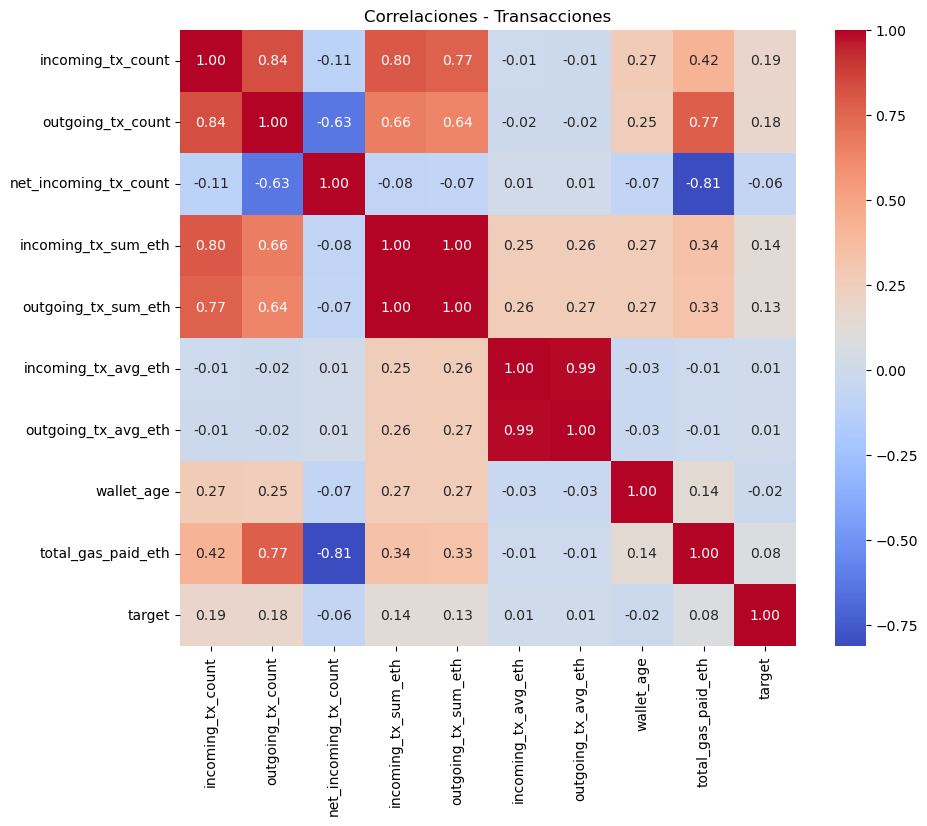

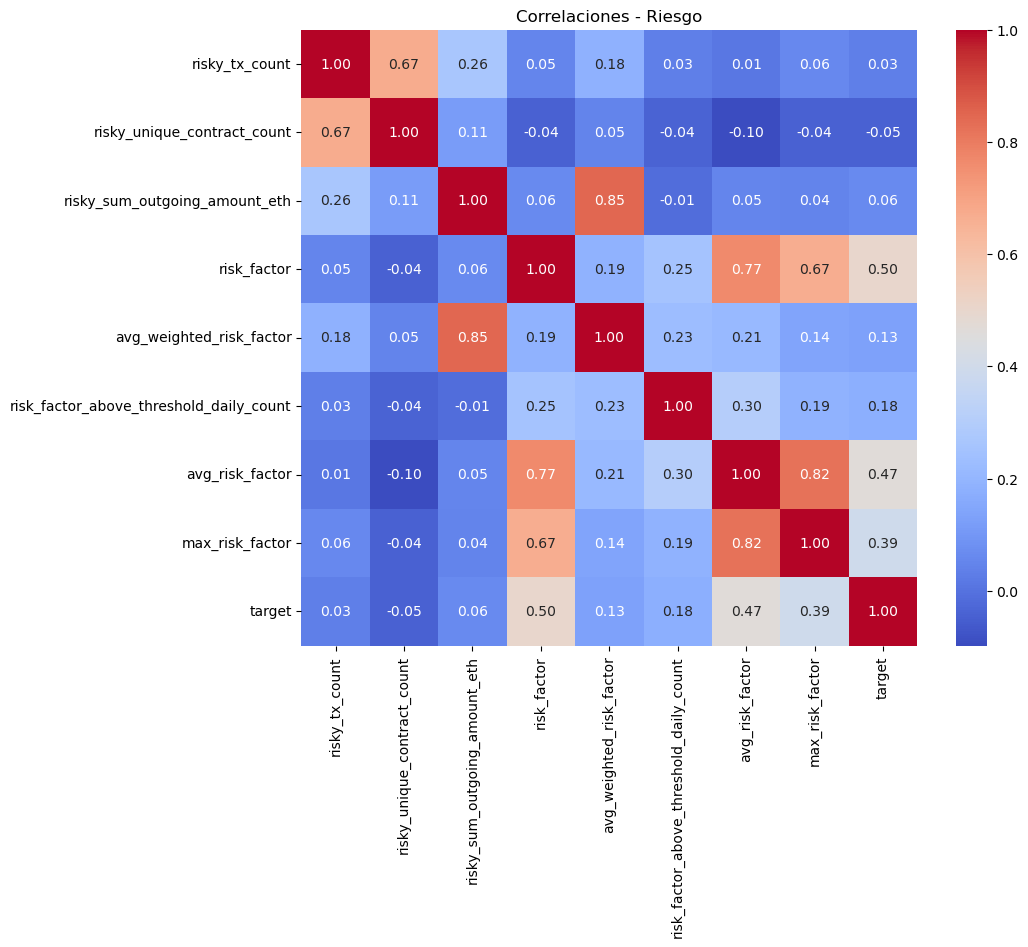

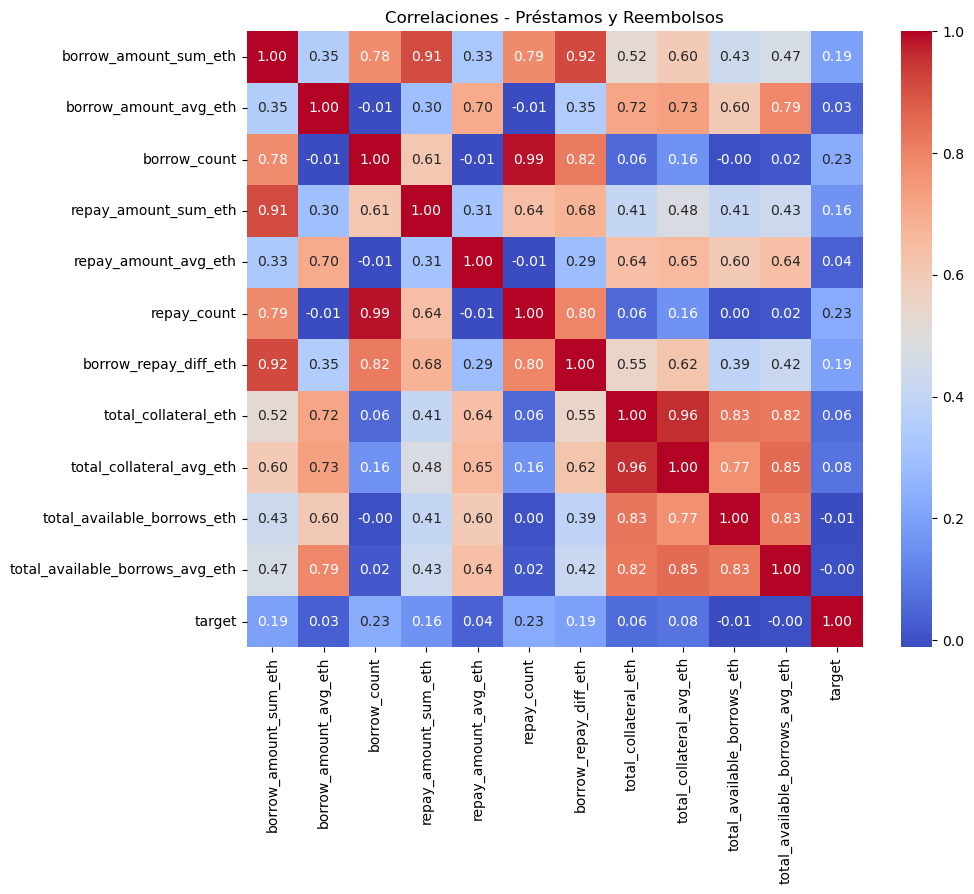

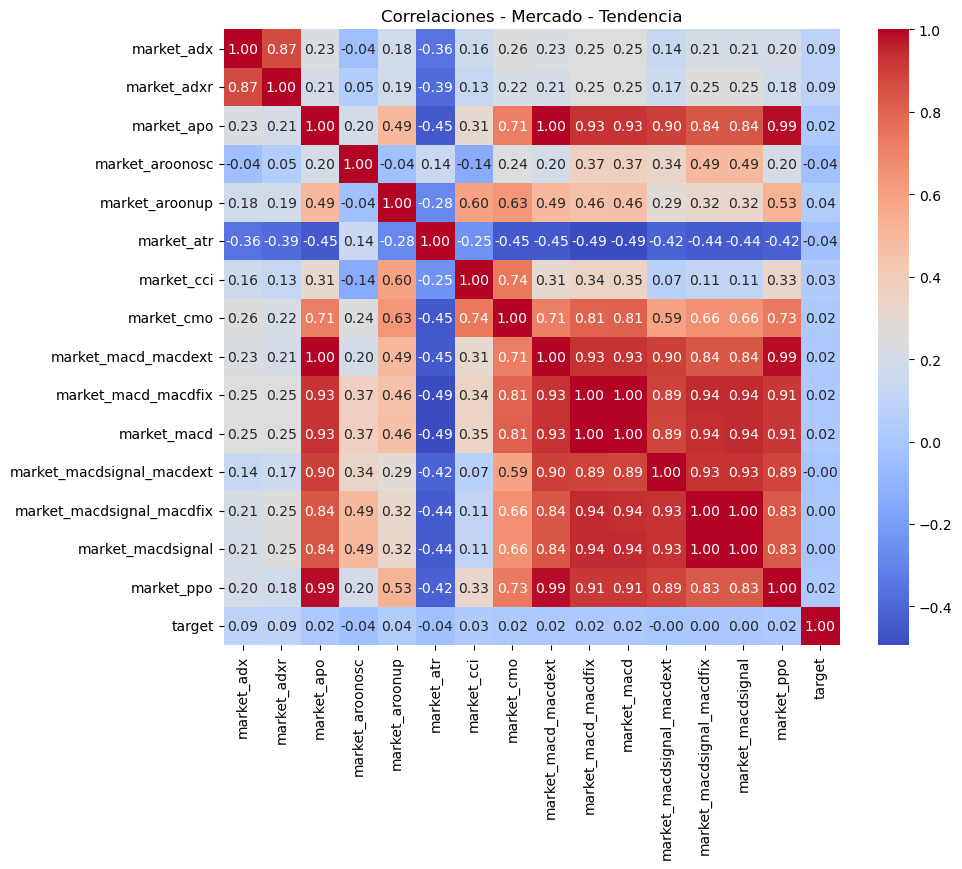

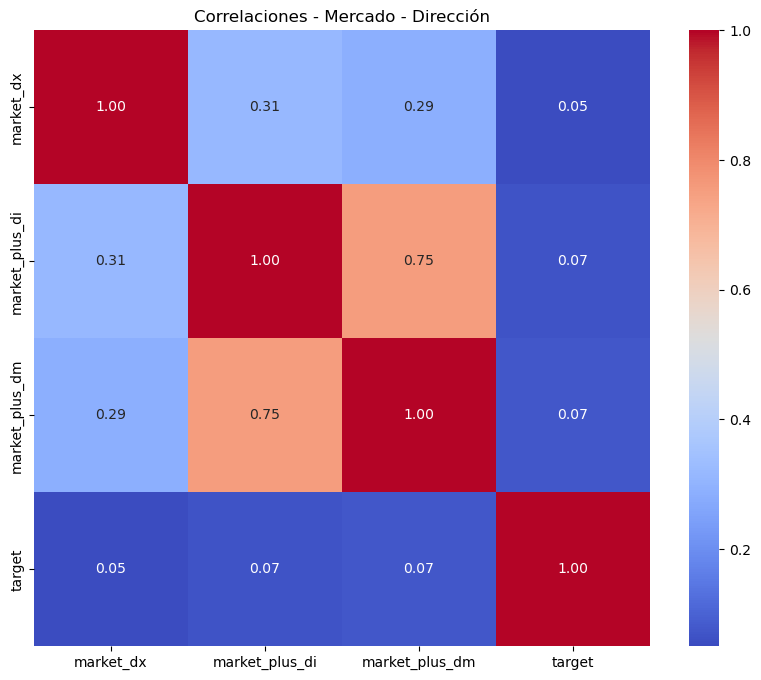

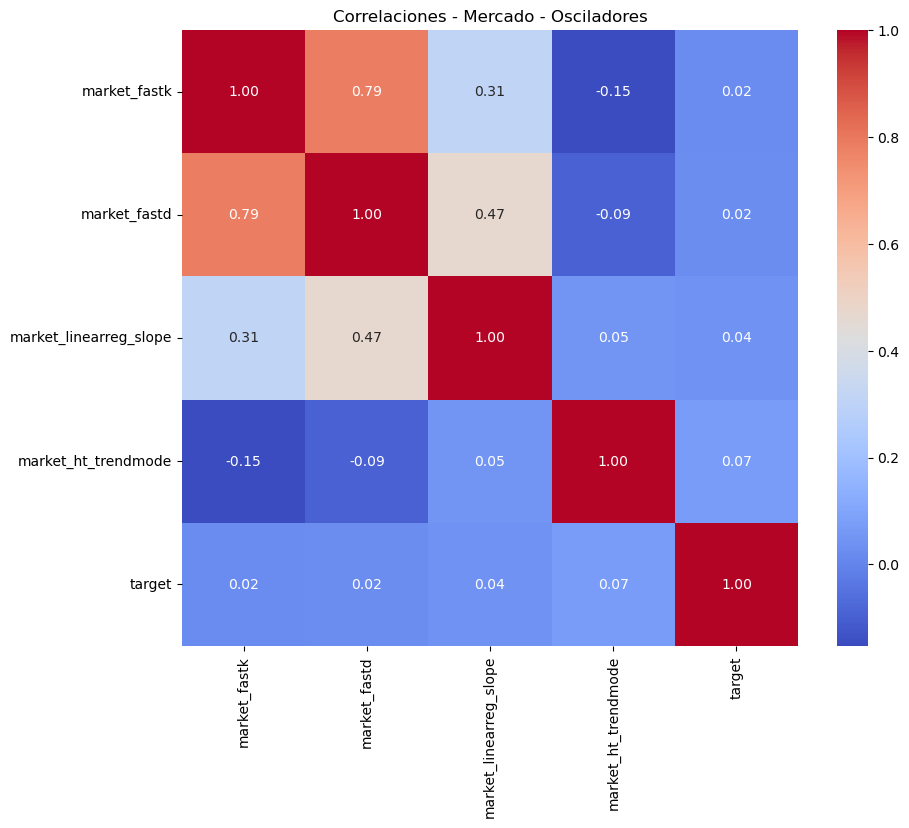

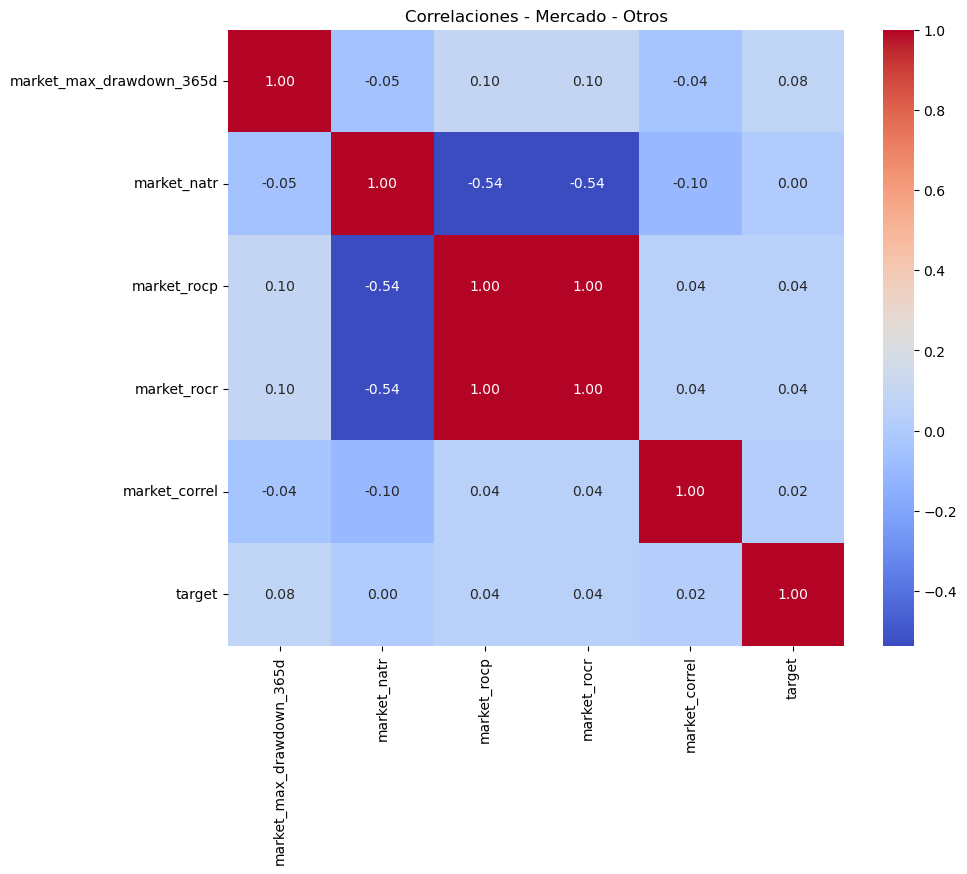

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separar las variables en grupos lógicos
transacciones = [
    "incoming_tx_count", "outgoing_tx_count", "net_incoming_tx_count",
    "incoming_tx_sum_eth", "outgoing_tx_sum_eth", "incoming_tx_avg_eth",
    "outgoing_tx_avg_eth", "wallet_age", "total_gas_paid_eth"
]

riesgo = [
    "risky_tx_count", "risky_unique_contract_count", "risky_sum_outgoing_amount_eth",
    "risk_factor", "avg_weighted_risk_factor", "risk_factor_above_threshold_daily_count",
    "avg_risk_factor", "max_risk_factor"
]

prestamos_reembolsos = [
    "borrow_amount_sum_eth", "borrow_amount_avg_eth", "borrow_count",
    "repay_amount_sum_eth", "repay_amount_avg_eth", "repay_count",
    "borrow_repay_diff_eth", "total_collateral_eth", "total_collateral_avg_eth",
    "total_available_borrows_eth", "total_available_borrows_avg_eth"
]

# Separar las variables de 'mercado' en subgrupos más detallados
mercado_tendencia = [
    "market_adx", "market_adxr", "market_apo", "market_aroonosc", "market_aroonup",
    "market_atr", "market_cci", "market_cmo", "market_macd_macdext", "market_macd_macdfix",
    "market_macd", "market_macdsignal_macdext", "market_macdsignal_macdfix", "market_macdsignal",
    "market_ppo"
]

mercado_direccion = [
    "market_dx", "market_plus_di", "market_plus_dm"
]

mercado_osciladores = [
    "market_fastk", "market_fastd", "market_linearreg_slope", "market_ht_trendmode"
]

mercado_otros = [
    "market_max_drawdown_365d", "market_natr", "market_rocp", "market_rocr", "market_correl"
]

# Definir una función para visualizar mapas de calor
def plot_heatmap(correlation_data, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        correlation_data,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        cbar=True,
        square=True
    )
    plt.title(title)
    plt.show()

# Calcular correlaciones y graficar por grupo
for grupo, nombre in zip(
    [transacciones, riesgo, prestamos_reembolsos, mercado_tendencia, mercado_direccion, mercado_osciladores, mercado_otros],
    ["Transacciones", "Riesgo", "Préstamos y Reembolsos", "Mercado - Tendencia", "Mercado - Dirección", "Mercado - Osciladores", "Mercado - Otros"]
):
    correlaciones = data[grupo + ["target"]].corr()
    plot_heatmap(correlaciones, f"Correlaciones - {nombre}")



Viendo la correlaciones, tenemos que risk_factor esta altamente relacionado con target, tambien risk_factor_above_threeshold_daily_count, tambien borrow_amount_sum_eth, borrow_count, y incoming_tk_count, y del mercado habia ninguna tan relevante (VER SI AGREGAR repay_amount_sum_eth y outgoing_tx_count)

No hay nulos ni duplicados

Preprocesamiento


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Separar X y target
X = data.drop(columns=["target"])  # Excluir la columna target
y = data["target"]

# Identificar las variables numéricas
numeric_features = X.select_dtypes(include=["float", "int"]).columns

# Definir la transformación de estandarización
scale_transformations = Pipeline([("scaler", StandardScaler())])

# Configurar el ColumnTransformer
column_transformer = ColumnTransformer(
    transformers=[
        ("scale", scale_transformations, numeric_features),
    ],
    remainder="drop"  # Ignora columnas que no están en numeric_features
)

# Aplicar transformaciones
X_preprocessed = column_transformer.fit_transform(X)

# Convertir a DataFrame con los nombres originales
X_preprocessed = pd.DataFrame(X_preprocessed, columns=numeric_features)

# Verificar dimensiones y resultado
print("Dimensiones de X_preprocessed:", X_preprocessed.shape)
print(X_preprocessed.head())


Dimensiones de X_preprocessed: (44296, 76)
   borrow_block_number  borrow_timestamp  first_tx_timestamp  \
0            -2.099846         -2.089374           -0.439243   
1            -2.099838         -2.089361           -0.439243   
2            -2.099834         -2.089356           -0.439243   
3            -2.099132         -2.088662            0.240767   
4            -2.097974         -2.087515            0.241650   

   last_tx_timestamp  wallet_age  incoming_tx_count  outgoing_tx_count  \
0          -2.081337   -0.326625          -0.261122          -0.234284   
1          -2.081315   -0.326620          -0.260796          -0.234030   
2          -2.081302   -0.326619          -0.260469          -0.233776   
3          -2.081293   -1.015413          -0.323436          -0.331325   
4          -2.079463   -1.015884          -0.325393          -0.344789   

   net_incoming_tx_count  total_gas_paid_eth  avg_gas_paid_per_tx_eth  ...  \
0               0.056233           -0.173391     

SELECCION DE FEATURES

In [16]:
# Variables seleccionadas basadas en las correlaciones
selected_features = [
    'risk_factor',
    'risk_factor_above_threshold_daily_count',
    'borrow_amount_sum_eth',
    'borrow_count',
    'incoming_tx_count',
]

# Seleccionar solo las columnas relevantes de X
X_selected = X_preprocessed[selected_features]


3. DIVIDIR LOS DATOS

In [17]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento y prueba (70%/30%)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42, stratify=y)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)


Dimensiones de X_train: (31007, 5)
Dimensiones de X_test: (13289, 5)


4. MODELO BASELINE

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve

pipeline = Pipeline([
    ('transformaciones', scale_transformations),
    ('modelo', LogisticRegression(random_state=42))
])

# Entrenar el modelo
pipeline.fit(X_train, y_train)

# Predecir con el modelo en los datos de test
y_pred_baseline = pipeline.predict(X_test)

# Evaluar el modelo utilizando classification_report
print("Classification Report:")
print(classification_report(y_test, y_pred_baseline))

# Calcular el AUC-PR
y_scores = pipeline.predict_proba(X_test)[:, 1] # Probabilidades predichas por el modelo
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
auc_pr = auc(recall, precision)

print("AUC-PR:", auc_pr)

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.68      0.70      6492
           1       0.71      0.76      0.73      6797

    accuracy                           0.72     13289
   macro avg       0.72      0.72      0.72     13289
weighted avg       0.72      0.72      0.72     13289

AUC-PR: 0.8509363613575166


5. MODELOS MACHINE LEARNING

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Crear pipelines para cada modelo
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf_model', RandomForestClassifier(random_state=42))
])

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_model', SVC(probability=True, random_state=42))  
])

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb_model', XGBClassifier(random_state=42))
])

# Entrenar los modelos
rf_pipeline.fit(X_train, y_train)
svm_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb_model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=None, gpu_id=None,
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, n_estimators=100,
                               n_jobs=None, num_parallel_tree=None,
                               predictor=None, random_state=42, ...))])

6. INTERPRETABILIDAD

Precision, recall y f1 score

In [25]:
# Evaluar los modelos
y_pred_rf = rf_pipeline.predict(X_test)
y_pred_svm = svm_pipeline.predict(X_test)
y_pred_xgb = xgb_pipeline.predict(X_test)

# Evaluar los modelos utilizando classification_report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Calcular el AUC-PR para cada modelo
y_scores_rf = rf_pipeline.predict_proba(X_test)[:, 1]
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_scores_rf)
auc_pr_rf = auc(recall_rf, precision_rf)
print("Random Forest AUC-PR:", auc_pr_rf)

y_scores_svm = svm_pipeline.predict_proba(X_test)[:, 1]
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_scores_svm)
auc_pr_svm = auc(recall_svm, precision_svm)
print("SVM AUC-PR:", auc_pr_svm)

y_scores_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_scores_xgb)
auc_pr_xgb = auc(recall_xgb, precision_xgb)
print("XGBoost AUC-PR:", auc_pr_xgb)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82      6492
           1       0.86      0.75      0.80      6797

    accuracy                           0.81     13289
   macro avg       0.81      0.81      0.81     13289
weighted avg       0.82      0.81      0.81     13289

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.88      0.78      6492
           1       0.84      0.63      0.72      6797

    accuracy                           0.75     13289
   macro avg       0.77      0.75      0.75     13289
weighted avg       0.77      0.75      0.75     13289

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81      6492
           1       0.86      0.73      0.79      6797

    accuracy                           0.80     13289
   macro avg       0.81      0.80

In [26]:
from sklearn.metrics import classification_report

# Para el modelo baseline
print("Baseline Model - Classification Report:")
print(classification_report(y_test, y_pred_baseline))

# Para el modelo SVM
print("Random Forest Model - Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Para el modelo 2
print("SVM Model - Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Para el modelo 3
print("XGBoost Model- Classification Report:")
print(classification_report(y_test, y_pred_xgb))


Baseline Model - Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.68      0.70      6492
           1       0.71      0.76      0.73      6797

    accuracy                           0.72     13289
   macro avg       0.72      0.72      0.72     13289
weighted avg       0.72      0.72      0.72     13289

Random Forest Model - Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82      6492
           1       0.86      0.75      0.80      6797

    accuracy                           0.81     13289
   macro avg       0.81      0.81      0.81     13289
weighted avg       0.82      0.81      0.81     13289

SVM Model - Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.88      0.78      6492
           1       0.84      0.63      0.72      6797

    accuracy                           0.75     13289
   macro

En un modelo de riesgo crediticio, perder a un moroso (falso negativo) puede ser extremadamente costoso, ya que implica no identificar a un cliente con alto riesgo de impago. Aunque es posible que algunos clientes no morosos sean identificados incorrectamente como morosos (falsos positivos), es preferible actuar sobre más clientes que podrían estar en riesgo, que no actuar sobre aquellos que realmente lo están.

En este contexto, se observa que el modelo Random Forest tiene un mejor F1 score, lo que indica que logra un mejor equilibrio entre la capacidad de detectar morosos y evitar falsos positivos. Sin embargo, dado el contexto del riesgo crediticio, nos interesa más el recall, ya que esta métrica refleja la capacidad del modelo para identificar correctamente a los morosos. Es crucial que el modelo tenga un bajo número de falsos negativos, es decir, que no asigne a un cliente como no moroso cuando realmente lo es. Un falso negativo en este caso significa que el modelo predice que alguien pagará cuando, en realidad, no lo hará.

Tanto Random Forest como XGBoost muestran un mejor rendimiento en términos de recall, lo que significa que son más efectivos para identificar a los morosos. Además, en cuanto a precision, estos dos modelos también destacan por su buen desempeño.

In [27]:


# y_true: valores reales
# y_scores: probabilidades predichas por el modelo
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_rf)
auc_pr_rf = auc(recall, precision)
# y_true: valores reales
# y_scores: probabilidades predichas por el modelo
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_svm)
auc_pr_svm = auc(recall, precision)
# y_true: valores reales
# y_scores: probabilidades predichas por el modelo
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_xgb)
auc_pr_xgb = auc(recall, precision)


# Calcular el accuracy de cada modelo
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"Accuracy del modelo Random Forest: {accuracy_rf}")
print(f"Accuracy del modelo SVM: {accuracy_svm}")
print(f"Accuracy del modelo XGBoost: {accuracy_xgb}")
print("AUC-PR del modelo Random Forest:", auc_pr_rf)
print("AUC-PR del modelo SVM:", auc_pr_svm)
print("AUC-PR del modelo XGBoost:", auc_pr_xgb)

Accuracy del modelo Random Forest: 0.8096169764466852
Accuracy del modelo SVM: 0.7519000677251862
Accuracy del modelo XGBoost: 0.8011137030626834
AUC-PR del modelo Random Forest: 0.8691641899546728
AUC-PR del modelo SVM: 0.8316164065459986
AUC-PR del modelo XGBoost: 0.864686044475746


Según el AUC-PR (Área Bajo la Curva Precision-Recall), esta métrica nos muestra la probabilidad de clasificar correctamente una instancia positiva, en este caso, una instancia positiva representa a un cliente moroso. El modelo baseline, que fue una regresión logística, obtuvo un AUC-PR de 0.796, lo cual es inferior en comparación con los tres modelos de Machine Learning más sofisticados.

El mejor desempeño lo obtuvo el modelo XGBoost, con un AUC-PR de 0.87, lo que se puede interpretar como que el modelo tiene un 87% de probabilidad de clasificar correctamente a un cliente como moroso. Sin embargo, el Random Forest obtuvo un rendimiento muy similar, con un AUC-PR de 0.869, lo que lo coloca en una posición competitiva. Por lo tanto, ambos modelos, Random Forest y XGBoost, son excelentes candidatos para la tarea de predecir la probabilidad de morosidad de los clientes.

El AUC-PR busca un equilibrio entre la precisión y el recall, lo que permite evaluar de manera más efectiva el desempeño del modelo en escenarios desbalanceados, como el que se presenta en este caso, donde los clientes morosos representan una fracción menor del total.

Calculo del rendimiento de los modelos con nuevos datos

In [28]:
#Cargamos los nuevos datos de X
X_2 = pd.read_parquet("X_t1.parquet")
print(X_2.head())

       borrow_block_number  borrow_timestamp  \
44296             10336632      1.593110e+09   
44297             10336644      1.593110e+09   
44298             10336670      1.593111e+09   
44299             10336675      1.593111e+09   
44300             10336679      1.593111e+09   

                                   wallet_address  first_tx_timestamp  \
44296  0x585bb700e2cdb34e8857bcf156df116636992825        1.551772e+09   
44297  0x2d0b0664d55ddc851561678bbe97d538ae78ed72        1.565473e+09   
44298  0x25f810cd651e4de4814f519a0ad27c5e7a50338d        1.496321e+09   
44299  0xd09051f120a79abe6c706285810cb8c199e1ce65        1.563614e+09   
44300  0xc68914cb0fbd2ae5888035abe36aa3bc8722ac7c        1.593109e+09   

       last_tx_timestamp  wallet_age  incoming_tx_count  outgoing_tx_count  \
44296       1.593110e+09  41337993.0                 12                 14   
44297       1.593110e+09  27637657.0                189                217   
44298       1.593106e+09  96789742.0  

In [29]:
print(y.info())

<class 'pandas.core.series.Series'>
RangeIndex: 44296 entries, 0 to 44295
Series name: target
Non-Null Count  Dtype
--------------  -----
44296 non-null  int64
dtypes: int64(1)
memory usage: 346.2 KB
None


In [30]:
# Aplicar transformaciones a los nuevos datos
X_preprocessed2 = column_transformer.fit_transform(X_2)

# Convertir a DataFrame con los nombres originales
X_preprocessed2 = pd.DataFrame(X_preprocessed2, columns=numeric_features)

# Verificar dimensiones y resultado
print("Dimensiones de X_preprocessed2:", X_preprocessed2.shape)
print(X_preprocessed2.head())

Dimensiones de X_preprocessed2: (44296, 76)
   borrow_block_number  borrow_timestamp  first_tx_timestamp  \
0            -1.339485         -1.341666           -0.474467   
1            -1.339447         -1.341618           -0.086299   
2            -1.339366         -1.341561           -2.045530   
3            -1.339350         -1.341550           -0.138958   
4            -1.339337         -1.341545            0.696710   

   last_tx_timestamp  wallet_age  incoming_tx_count  outgoing_tx_count  \
0          -1.331626    0.315960          -0.242751          -0.220327   
1          -1.331599   -0.075314          -0.180719          -0.176867   
2          -1.332583    1.899630          -0.237494          -0.216474   
3          -1.331633   -0.022225          -0.187027          -0.174512   
4          -1.331504   -0.864591          -0.245555          -0.222682   

   net_incoming_tx_count  total_gas_paid_eth  avg_gas_paid_per_tx_eth  ...  \
0               0.106117           -0.242470    

In [31]:
# Variables seleccionadas basadas en las correlaciones
selected_features = [
    'risk_factor',
    'risk_factor_above_threshold_daily_count',
    'borrow_amount_sum_eth',
    'borrow_count',
    'incoming_tx_count'
]

# Seleccionar solo las columnas relevantes de X
X_selected2 = X_preprocessed2[selected_features]

# Verificar dimensiones y resultado
print("Dimensiones de X_preprocessed2:", X_selected2.shape)
print(X_selected2.head())

Dimensiones de X_preprocessed2: (44296, 5)
   risk_factor  risk_factor_above_threshold_daily_count  \
0    -1.151763                                -0.083415   
1     0.496438                                -0.083415   
2    -1.151763                                -0.083408   
3    -1.151763                                -0.083415   
4    -1.151763                                -0.083415   

   borrow_amount_sum_eth  borrow_count  incoming_tx_count  
0              -0.153241     -0.186006          -0.242751  
1              -0.152963     -0.167446          -0.180719  
2              -0.153060     -0.167446          -0.237494  
3              -0.153241     -0.186006          -0.187027  
4              -0.153241     -0.186006          -0.245555  


In [32]:
# Evaluar los modelos con X_t1
y_pred_rf2 = rf_pipeline.predict(X_selected2)
y_pred_svm2 = svm_pipeline.predict(X_selected2)
y_pred_xgb2 = xgb_pipeline.predict(X_selected2)

precision, recall, thresholds = precision_recall_curve(y, y_pred_rf2)
auc_pr_rf2 = auc(recall, precision)

precision, recall, thresholds = precision_recall_curve(y, y_pred_svm2)
auc_pr_svm2 = auc(recall, precision)

precision, recall, thresholds = precision_recall_curve(y, y_pred_xgb2)
auc_pr_xgb2 = auc(recall, precision)

In [33]:
print("AUC-PR del modelo Random Forest:", auc_pr_rf2)
print("AUC-PR del modelo SVM:", auc_pr_svm2)
print("AUC-PR del modelo XGBoost:", auc_pr_xgb2)

AUC-PR del modelo Random Forest: 0.7540873817841554
AUC-PR del modelo SVM: 0.6062261905495323
AUC-PR del modelo XGBoost: 0.7550476030518862


In [34]:
from zipfile import ZipFile
import os
def generateFiles(predict_data, clf_pipe):
    """Genera los archivos a subir en CodaLab

    Input
    ---------------
    predict_data: Dataframe con los datos de entrada a predecir
    clf_pipe: pipeline del clf

    Ouput
    ---------------
    archivo de txt
    """
    y_pred_clf = clf_pipe.predict_proba(predict_data)[:, 1]
    with open('./predictions.txt', 'w') as f:
        for item in y_pred_clf:
            f.write("%s\n" % item)
    
    with ZipFile('predictions.zip', 'w') as zipObj:
        zipObj.write('predictions.txt')
    os.remove('predictions.txt')

generateFiles(X_selected2, xgb_pipeline)

In [35]:
print(y.info())

<class 'pandas.core.series.Series'>
RangeIndex: 44296 entries, 0 to 44295
Series name: target
Non-Null Count  Dtype
--------------  -----
44296 non-null  int64
dtypes: int64(1)
memory usage: 346.2 KB
None


Etapa 2


Carga y preprocesamiento de datos

In [40]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Cargar datos
X = pd.read_parquet("X_t0.parquet")
y = pd.read_parquet("y_t0.parquet")

# Combinar los datos para facilitar el análisis
data = X.copy()
data["target"] = y.values

# Separar X y target
X = data.drop(columns=["target"])
y = data["target"]

# Identificar las variables numéricas
numeric_features = X.select_dtypes(include=["float", "int"]).columns

# Definir la transformación de estandarización e imputación
scale_transformations = Pipeline([
    ("scaler", StandardScaler())
])

# Configurar el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("scale", scale_transformations, numeric_features),
    ],
    remainder="drop"  # Eliminar columnas que no están en numeric_features
)

In [41]:
# Aplicar el preprocesador a los datos completos
X_preprocessed = preprocessor.fit_transform(X)

# Convertir a DataFrame para mantener los nombres de las columnas
# Usar las columnas originales más las nuevas columnas generadas por el preprocesador
all_columns = numeric_features.tolist() + [f"passthrough_{i}" for i in range(X_preprocessed.shape[1] - len(numeric_features))]
X_preprocessed = pd.DataFrame(X_preprocessed, columns=all_columns)

# Asegurarse de que las columnas sean numéricas
X_preprocessed = X_preprocessed.apply(pd.to_numeric, errors='coerce')

# Verificar el tipo de datos de las columnas
print(X_preprocessed.dtypes)

# Verificar si hay valores nulos
print(X_preprocessed.isnull().sum())

borrow_block_number              float64
borrow_timestamp                 float64
first_tx_timestamp               float64
last_tx_timestamp                float64
wallet_age                       float64
                                  ...   
market_ppo                       float64
market_rocp                      float64
market_rocr                      float64
unique_borrow_protocol_count     float64
unique_lending_protocol_count    float64
Length: 76, dtype: object
borrow_block_number              0
borrow_timestamp                 0
first_tx_timestamp               0
last_tx_timestamp                0
wallet_age                       0
                                ..
market_ppo                       0
market_rocp                      0
market_rocr                      0
unique_borrow_protocol_count     0
unique_lending_protocol_count    0
Length: 76, dtype: int64


In [42]:
X_preprocessed.head(5)

,borrow_block_number,borrow_timestamp,first_tx_timestamp,last_tx_timestamp,wallet_age,incoming_tx_count,outgoing_tx_count,net_incoming_tx_count,total_gas_paid_eth,avg_gas_paid_per_tx_eth,...,market_macdsignal,market_max_drawdown_365d,market_natr,market_plus_di,market_plus_dm,market_ppo,market_rocp,market_rocr,unique_borrow_protocol_count,unique_lending_protocol_count
0,-2.099846,-2.089374,-0.439243,-2.081337,-0.326625,-0.261122,-0.234284,0.056233,-0.173391,-0.232649,...,-0.035233,-2.757783,-0.687659,1.195731,-0.056625,-0.329363,0.722749,0.722749,-2.350667,0.175051
1,-2.099838,-2.089361,-0.439243,-2.081315,-0.326620,-0.260796,-0.234030,0.056233,-0.173266,-0.232440,...,-0.035233,-2.757783,-0.687659,1.195731,-0.056625,-0.329363,0.722749,0.722749,0.425411,0.175051
2,-2.099834,-2.089356,-0.439243,-2.081302,-0.326619,-0.260469,-0.233776,0.056233,-0.173129,-0.232184,...,-0.035233,-2.757783,-0.687659,1.195731,-0.056625,-0.329363,0.722749,0.722749,0.425411,0.175051
3,-2.099132,-2.088662,0.240767,-2.081293,-1.015413,-0.323436,-0.331325,0.144352,-0.157949,0.972234,...,-0.035233,-2.757783,-0.687659,1.195731,-0.056625,-0.329363,0.722749,0.722749,-2.350667,0.175051
4,-2.097974,-2.087515,0.241650,-2.079463,-1.015884,-0.325393,-0.344789,0.166036,-0.202867,-0.230024,...,-0.035233,-2.757783,-0.687659,1.195731,-0.056625,-0.329363,0.722749,0.722749,-2.350667,0.175051


In [43]:
from feature_engine.selection import SmartCorrelatedSelection

# Selección de características con SmartCorrelatedSelection
correlation_selector = SmartCorrelatedSelection(
    variables=None,
    method="pearson",
    threshold=0.5,
    missing_values="raise",
    selection_method="variance",
    estimator=None,
)

# Ajustar y transformar los datos
X_selected = correlation_selector.fit_transform(X_preprocessed)

# Verificar las columnas seleccionadas
print("Columnas seleccionadas:", X_selected.columns)

Columnas seleccionadas: Index(['first_tx_timestamp', 'last_tx_timestamp', 'total_gas_paid_eth',
       'avg_gas_paid_per_tx_eth', 'risky_unique_contract_count',
       'risky_sum_outgoing_amount_eth', 'max_eth_ever', 'min_eth_ever',
       'total_balance_eth', 'max_risk_factor', 'borrow_count',
       'time_since_first_deposit', 'withdraw_deposit_diff_if_positive_eth',
       'time_since_last_liquidated', 'market_adxr', 'market_correl',
       'market_dx', 'market_fastd', 'market_ht_trendmode',
       'market_max_drawdown_365d', 'market_plus_dm', 'market_ppo',
       'unique_lending_protocol_count'],
      dtype='object')


In [44]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento y prueba (70%/30%)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42, stratify=y)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)

Dimensiones de X_train: (31007, 23)
Dimensiones de X_test: (13289, 23)


In [45]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Pipeline con el modelo XGBoost
XGB_pipe = Pipeline([
    ("classifier", XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

# Función para entrenar y evaluar el modelo
def train_and_evaluate(pipeline):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print(classification_report(y_test, y_pred))

# Entrenar y evaluar el modelo
train_and_evaluate(XGB_pipe)

/home/toti/miniconda3/envs/MDS/lib/python3.12/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


              precision    recall  f1-score   support

           0       0.84      0.91      0.87      6492
           1       0.90      0.84      0.87      6797

    accuracy                           0.87     13289
   macro avg       0.87      0.87      0.87     13289
weighted avg       0.87      0.87      0.87     13289



In [46]:
from sklearn.metrics import precision_recall_curve, auc

# Asegúrate de que el modelo XGBoost esté entrenado
XGB_pipe.fit(X_train, y_train)

# Predecir con el modelo XGBoost optimizado
y_pred_xgb = XGB_pipe.predict(X_test)
y_scores_xgb = XGB_pipe.predict_proba(X_test)[:, 1]  # Probabilidades predichas por el modelo

# Calcular precisión, recall y AUC-PR
precision, recall, thresholds = precision_recall_curve(y_test, y_scores_xgb)
auc_pr_xgb = auc(recall, precision)

print("AUC-PR del modelo XGBoost:", auc_pr_xgb)

AUC-PR del modelo XGBoost: 0.9524881962823071


In [47]:
import optuna

# Definir la función objetivo para Optuna
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 2, 20)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    
    pipeline = Pipeline([
        ("classifier", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    
    return f1

# Crear un estudio y optimizar
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Mostrar los mejores hiperparámetros
print("Mejores hiperparámetros:", study.best_params)

[I 2024-12-12 17:42:46,575] A new study created in memory with name: no-name-713f75f7-f8b0-467d-958e-8b5cf9879679
/home/toti/miniconda3/envs/MDS/lib/python3.12/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2024-12-12 17:42:59,219] Trial 0 finished with value: 0.8583083198645425 and parameters: {'n_estimators': 233, 'max_depth': 7, 'learning_rate': 0.06963337843675951}. Best is trial 0 with value: 0.8583083198645425.
/home/toti/miniconda3/envs/MDS/lib/python3.12/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
[I 2024-12-12 17:43:00,974] Trial 1 finished with value: 0.7533862680990191 and parameters: {'n_estimators': 128, 'max_depth': 2, 'learning_rate': 0.052961035465473615}. Best is trial 0 with value: 0.8583083198645425.
/home/toti/miniconda3/envs/MDS/lib/python

Mejores hiperparámetros: {'n_estimators': 290, 'max_depth': 11, 'learning_rate': 0.2812443699796401}


In [72]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve
from xgboost import XGBClassifier

# Obtener los mejores hiperparámetros
best_params = study.best_params

# Crear el modelo con los mejores hiperparámetros
final_model = XGBClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Entrenar el modelo final con el conjunto de entrenamiento completo
final_model.fit(X_train, y_train)

# Evaluar el modelo en el conjunto de prueba
y_pred = final_model.predict(X_test)

# Calcular las probabilidades para la clase positiva
y_proba = final_model.predict_proba(X_test)[:, 1]

# Calcular el AUC-ROC
auc_roc = roc_auc_score(y_test, y_proba)
print("\nAUC-ROC en el conjunto de prueba:", auc_roc)

# Opcional: Obtener la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Métricas de evaluación
f1 = f1_score(y_test, y_pred)
print("\nF1 Score en el conjunto de prueba:", f1)

# Informe de clasificación detallado
print("\nInforme de clasificación:\n", classification_report(y_test, y_pred))

# Matriz de confusión
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))



/home/toti/miniconda3/envs/MDS/lib/python3.12/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")



AUC-ROC en el conjunto de prueba: 0.9694045300693077

F1 Score en el conjunto de prueba: 0.9113904991342318

Informe de clasificación:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91      6492
           1       0.93      0.89      0.91      6797

    accuracy                           0.91     13289
   macro avg       0.91      0.91      0.91     13289
weighted avg       0.91      0.91      0.91     13289


Matriz de confusión:
 [[6059  433]
 [ 744 6053]]


3. re entrenamiento del modelo


In [69]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, auc, average_precision_score
import numpy as np

# Cargar los datos
X = pd.read_parquet("X_t0.parquet")
y = pd.read_parquet("y_t0.parquet")
# Eliminar columnas de tipo object
X = X.select_dtypes(include=[np.number])

# Verificar las columnas restantes
print("Columnas después de eliminar las de tipo object:", X.columns)

# Dividir los datos en entrenamiento y prueba (70%/30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Crear el DMatrix para XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Parámetros del modelo
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42
}



# Entrenar el modelo inicial
bst = xgb.train(params, dtrain, num_boost_round=100)

# Guardar el modelo inicial
bst.save_model('xgb_model_initial.json')

Columnas después de eliminar las de tipo object: Index(['borrow_block_number', 'borrow_timestamp', 'first_tx_timestamp',
       'last_tx_timestamp', 'wallet_age', 'incoming_tx_count',
       'outgoing_tx_count', 'net_incoming_tx_count', 'total_gas_paid_eth',
       'avg_gas_paid_per_tx_eth', 'risky_tx_count',
       'risky_unique_contract_count', 'risky_first_tx_timestamp',
       'risky_last_tx_timestamp', 'risky_first_last_tx_timestamp_diff',
       'risky_sum_outgoing_amount_eth', 'outgoing_tx_sum_eth',
       'incoming_tx_sum_eth', 'outgoing_tx_avg_eth', 'incoming_tx_avg_eth',
       'max_eth_ever', 'min_eth_ever', 'total_balance_eth', 'risk_factor',
       'total_collateral_eth', 'total_collateral_avg_eth',
       'total_available_borrows_eth', 'total_available_borrows_avg_eth',
       'avg_weighted_risk_factor', 'risk_factor_above_threshold_daily_count',
       'avg_risk_factor', 'max_risk_factor', 'borrow_amount_sum_eth',
       'borrow_amount_avg_eth', 'borrow_count', 'repay_am

In [71]:
# Evaluar el modelo inicial
y_prob_initial = bst.predict(dtest)
precision_initial, recall_initial, _ = precision_recall_curve(y_test, y_prob_initial)
auc_pr_initial = average_precision_score(y_test, y_prob_initial)
print(f'AUC-PR del modelo inicial: {auc_pr_initial:.2f}')

AUC-PR del modelo inicial: 0.96


In [66]:
# Cargar los nuevos datos
X_t1 = pd.read_parquet("X_t1.parquet")
y_t1 = pd.read_parquet("y_t1.parquet")

# Eliminar columnas de tipo object
X_t1 = X_t1.select_dtypes(include=[np.number])

# Asegurarse de que X_t1 y y_t1 tengan el mismo número de filas
if len(y_t1) > len(X_t1):
    y_t1 = y_t1.iloc[:len(X_t1)]

# Verificar las dimensiones
print(f"Dimensiones de X_t1: {X_t1.shape}")
print(f"Dimensiones de y_t1: {y_t1.shape}")

Dimensiones de X_t1: (44296, 76)
Dimensiones de y_t1: (44296, 1)


In [67]:
def retrain_xgboost(model_path, X_new, y_new):
    # Cargar el modelo existente
    bst = xgb.Booster()
    bst.load_model(model_path)
    
    # Crear el DMatrix para los nuevos datos
    dnew = xgb.DMatrix(X_new, label=y_new)
    
    # Continuar entrenando el modelo con los nuevos datos
    bst = xgb.train(params, dnew, num_boost_round=100, xgb_model=bst)
    
    # Guardar el modelo actualizado
    bst.save_model('xgb_model_updated.json')
    
    return bst

# Re-entrenar el modelo con los nuevos datos
bst_updated = retrain_xgboost('xgb_model_initial.json', X_t1, y_t1)

[19:03:18] WARNING: ../src/learner.cc:767: 
Parameters: { "enable_categorical", "missing", "n_estimators", "use_label_encoder" } are not used.



In [70]:
# Crear el DMatrix para los datos de prueba
dtest_new = xgb.DMatrix(X_test)

# Evaluar el modelo reentrenado
y_new_prob = bst_updated.predict(dtest_new)
precision_new, recall_new, _ = precision_recall_curve(y_test, y_new_prob)
auc_pr_new = average_precision_score(y_test, y_new_prob)
print(f'AUC-PR del modelo reentrenado: {auc_pr_new:.2f}')

AUC-PR del modelo reentrenado: 0.93
